# EDA — NovaPay: Detección de Fraude (Ronda 1)

Dataset sintético generado por el equipo.
El objetivo es entender la distribución de las variables, identificar señales
asociadas al fraude y sentar las bases para el modelado.

**Estructura del notebook**
1. Setup e imports
2. Carga y exploración inicial
3. Análisis univariante
4. Análisis bivariante — Temporalidad y variables categóricas
5. Análisis bivariante — Variables numéricas vs `IS_FRAUD`
6. Correlaciones
7. Análisis multivariante — Interacciones

## 1. Setup e imports

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carga y exploración inicial

### 2.1 Carga del dataset

In [2]:
df = pd.read_csv('data/dataset_fraude.csv')
df.head()

,id_cliente,tipo_cliente,edad_cliente,customer_country,customer_region,tenure,importe_medio_mensual,desviacion_estandar_mensual,media_transacciones_al_dia,numero_fraudes_ultimo_ano,...,identificador_dispositivo_fingerprint,dispositivo_reconocido,operacion_pais,operacion_region,direccion_ip_origen,geolocalizacion,cuenta_destino,destino_alto_riesgo,IS_FRAUD,IMPACTO_FRAUDE
0,3ddebd45-ccd,empresa,57,ES,Centro,3364,21.97,292.59,1.58,0,...,fa1bdf50-1c95-45,1,ES,Centro,86.34.12.179,"40.4168,-3.7038",ES169540317577,0,0,0
1,12625769-3f8,persona,68,FR,Normandía,2068,283.70,1425.40,2.99,0,...,1d0337cd-8f7a-42,1,FR,Bretaña,90.14.61.52,"48.8566,2.3522",ES735546725072,1,0,0
2,b5768bae-00f,persona,62,PT,Oporto,1671,83.21,537.38,11.62,0,...,0bf03526-6f4e-42,1,PT,Oporto,85.128.118.137,"41.1579,-8.6291",ES833936678283,0,0,0
3,c3a35556-977,persona,79,ES,Este,3436,575.25,270.19,4.76,0,...,29a17329-bcec-42,1,ES,Sur,86.56.138.66,"40.4168,-3.7038",ES642797821786,0,0,0
4,46b228e3-b47,persona,73,DE,Hesse,3557,171.31,302.57,4.00,0,...,5854151e-c36e-41,1,DE,Hesse,87.220.5.4,"52.5200,13.4050",ES973327198270,0,0,0


### 2.2 Limpieza inicial

In [3]:
# IMPACTO_FRAUDE es una columna de impacto económico, no de clasificación — se elimina
if 'IMPACTO_FRAUDE' in df.columns:
    df.drop(columns=['IMPACTO_FRAUDE'], inplace=True)


### 2.3 Feature engineering temporal

Extraemos variables de `fecha_hora` para poder analizar patrones temporales.

In [4]:
# Descomponemos fecha_hora en variables discretas (hora, día, mes)
df['fecha_hora'] = pd.to_datetime(df['fecha_hora'])

df['fecha'] = df['fecha_hora'].dt.date
df['hora'] = df['fecha_hora'].dt.hour
df['dia_semana'] = df['fecha_hora'].dt.day_name()
df['mes'] = df['fecha_hora'].dt.month

### 2.4 Inspección del dataset

Revisamos valores nulos, tipos de datos y estadísticos básicos.

In [5]:
# Comprobación de valores nulos — el dataset sintético está completo
df.isna().sum().sort_values(ascending=False)

id_cliente                                0
tipo_cliente                              0
edad_cliente                              0
customer_country                          0
customer_region                           0
tenure                                    0
importe_medio_mensual                     0
desviacion_estandar_mensual               0
media_transacciones_al_dia                0
numero_fraudes_ultimo_ano                 0
id_cuenta                                 0
cuenta_origen                             0
estado_cuenta                             0
saldo_actual                              0
saldo_medio_30_dias                       0
volumen_entrante_30_dias                  0
volumen_saliente_30_dias                  0
numero_transferencias_recibidas_7_dias    0
numero_transferencias_enviadas_7_dias     0
id_tarjeta                                0
estado_tarjeta                            0
fecha_creacion_tarjeta                    0
antiguedad_tarjeta_dias         

In [6]:
# Tipos de datos y conteo de no-nulos por columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 48 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   id_cliente                              10000 non-null  str           
 1   tipo_cliente                            10000 non-null  str           
 2   edad_cliente                            10000 non-null  int64         
 3   customer_country                        10000 non-null  str           
 4   customer_region                         10000 non-null  str           
 5   tenure                                  10000 non-null  int64         
 6   importe_medio_mensual                   10000 non-null  float64       
 7   desviacion_estandar_mensual             10000 non-null  float64       
 8   media_transacciones_al_dia              10000 non-null  float64       
 9   numero_fraudes_ultimo_ano               10000 non-null  int64 

In [7]:
# Estadísticos descriptivos de todas las variables numéricas
df.describe()

,edad_cliente,tenure,importe_medio_mensual,desviacion_estandar_mensual,media_transacciones_al_dia,numero_fraudes_ultimo_ano,saldo_actual,saldo_medio_30_dias,volumen_entrante_30_dias,volumen_saliente_30_dias,...,is_weekend,tiempo_desde_ultima_transaccion,numero_transacciones_ultima_hora,importe_transaccion,numero_pin_disponibles,dispositivo_reconocido,destino_alto_riesgo,IS_FRAUD,hora,mes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,...,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,51.228900,1801.225000,860.610553,487.970697,3.345459,0.455700,3339.609429,3283.838537,9065.748711,1.040320e+04,...,0.284300,1.360110e+06,2.008100,473.109818,1.848100,0.849200,0.118900,0.152600,11.471200,4.957900
min,18.000000,1.000000,6.930000,0.080000,0.500000,0.000000,1.350000,1.460000,20.660000,1.277000e+01,...,0.000000,0.000000e+00,0.000000,0.520000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,34.000000,869.000000,192.380000,147.020000,1.340000,0.000000,401.210000,387.970000,1094.777500,1.132023e+03,...,0.000000,0.000000e+00,1.000000,54.382500,1.000000,1.000000,0.000000,0.000000,5.000000,2.000000
50%,50.000000,1792.000000,430.980000,352.380000,2.500000,0.000000,1024.610000,1043.840000,2964.450000,3.070215e+03,...,0.000000,4.361600e+04,2.000000,148.475000,2.000000,1.000000,0.000000,0.000000,11.000000,4.000000
75%,69.000000,2736.500000,956.230000,681.030000,4.430000,1.000000,2928.127500,2911.290000,8159.335000,8.401372e+03,...,1.000000,1.579065e+05,3.000000,409.747500,2.000000,1.000000,0.000000,0.000000,18.000000,5.000000
max,84.000000,3647.000000,44868.230000,4150.160000,22.450000,6.000000,294122.030000,325718.190000,609238.470000,1.501301e+06,...,1.000000,1.542519e+07,9.000000,27088.380000,3.000000,1.000000,1.000000,1.000000,23.000000,12.000000
std,19.861006,1051.031019,1741.871375,476.583989,2.810975,0.784282,9546.123277,9149.502512,24365.369485,4.551894e+04,...,0.451103,2.956285e+06,1.427459,1177.443036,0.726828,0.357872,0.323687,0.359619,6.955775,3.945945


In [8]:
# Detalle de importe_transaccion: media muy superior a la mediana → distribución sesgada a la derecha
df["importe_transaccion"].describe()

count    10000.000000
mean       473.109818
std       1177.443036
min          0.520000
25%         54.382500
50%        148.475000
75%        409.747500
max      27088.380000
Name: importe_transaccion, dtype: float64

In [9]:
# tiempo_desde_ultima_transaccion está en segundos (max ~15M seg ≈ 174 días)
df["tiempo_desde_ultima_transaccion"]

0          74408
1          76243
2          80407
3          18009
4          17633
          ...   
9995           0
9996           0
9997     2301189
9998    10511337
9999           0
Name: tiempo_desde_ultima_transaccion, Length: 10000, dtype: int64

In [10]:
# Listado completo de columnas tras el feature engineering
print('Columnas del dataset:')
print(df.columns.tolist())

Columnas del dataset:
['id_cliente', 'tipo_cliente', 'edad_cliente', 'customer_country', 'customer_region', 'tenure', 'importe_medio_mensual', 'desviacion_estandar_mensual', 'media_transacciones_al_dia', 'numero_fraudes_ultimo_ano', 'id_cuenta', 'cuenta_origen', 'estado_cuenta', 'saldo_actual', 'saldo_medio_30_dias', 'volumen_entrante_30_dias', 'volumen_saliente_30_dias', 'numero_transferencias_recibidas_7_dias', 'numero_transferencias_enviadas_7_dias', 'id_tarjeta', 'estado_tarjeta', 'fecha_creacion_tarjeta', 'antiguedad_tarjeta_dias', 'limite_importe_transacciones', 'veces_superar_limite_7_dias', 'id_transaccion', 'tipo_transaccion', 'fecha_hora', 'is_night', 'is_weekend', 'tiempo_desde_ultima_transaccion', 'numero_transacciones_ultima_hora', 'importe_transaccion', 'metodo_autenticacion', 'numero_pin_disponibles', 'identificador_dispositivo_fingerprint', 'dispositivo_reconocido', 'operacion_pais', 'operacion_region', 'direccion_ip_origen', 'geolocalizacion', 'cuenta_destino', 'destin

In [11]:
# Identificación de columnas de tipo objeto/categórico
categorical_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print('Columnas categÃ³ricas:')
print(categorical_cols)


Columnas categÃ³ricas:
['id_cliente', 'tipo_cliente', 'customer_country', 'customer_region', 'id_cuenta', 'cuenta_origen', 'estado_cuenta', 'id_tarjeta', 'estado_tarjeta', 'fecha_creacion_tarjeta', 'id_transaccion', 'tipo_transaccion', 'metodo_autenticacion', 'identificador_dispositivo_fingerprint', 'operacion_pais', 'operacion_region', 'direccion_ip_origen', 'geolocalizacion', 'cuenta_destino', 'fecha', 'dia_semana']


## 3. Análisis univariante

Exploramos la distribución individual de las variables más relevantes
y la variable objetivo.

### 3.1 Desbalanceo de clases

C:\Users\juan_\AppData\Local\Temp\ipykernel_21400\21065914.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=conteo_clases.values, palette=colors)


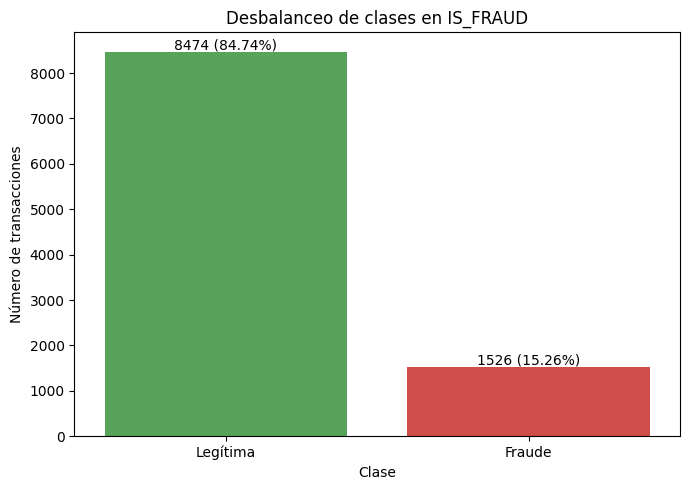

In [12]:
# Desbalanceo de clases
conteo_clases = df['IS_FRAUD'].value_counts().sort_index()
porcentaje_clases = df['IS_FRAUD'].value_counts(normalize=True).sort_index() * 100

labels = ['Legítima', 'Fraude']
colors = ['#4CAF50', '#E53935']

plt.figure(figsize=(7, 5))
ax = sns.barplot(x=labels, y=conteo_clases.values, palette=colors)

for i, v in enumerate(conteo_clases.values):
    plt.text(i, v + 50, f'{v} ({porcentaje_clases.iloc[i]:.2f}%)', ha='center')

plt.title('Desbalanceo de clases en IS_FRAUD')
plt.xlabel('Clase')
plt.ylabel('Número de transacciones')
plt.tight_layout()
plt.show()

> **Hallazgo 3.1 — Desbalanceo de clases:**  
> El dataset presenta una ratio de ~6,5:1 (legítimas/fraudulentas). Con solo el 15,26% de fraude, un clasificador que siempre prediga "no fraude" alcanzaría ~85% de accuracy — la métrica primaria debe ser **AUC-ROC, F1 o Precision-Recall**, no accuracy. En el modelado se aplicará `class_weight='balanced'` o SMOTE para compensar.

### 3.2 Distribuciones de variables de saldo y volumen

Comparamos la distribución de cada variable entre transacciones
fraudulentas y legítimas, primero en escala absoluta y luego normalizada.

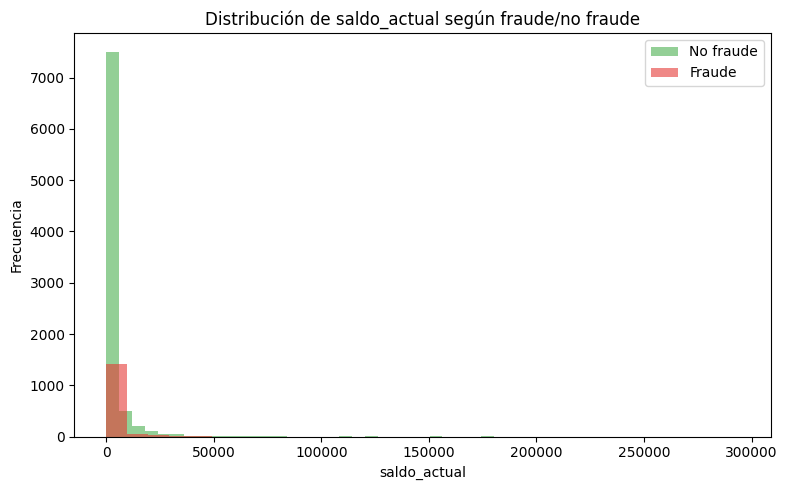

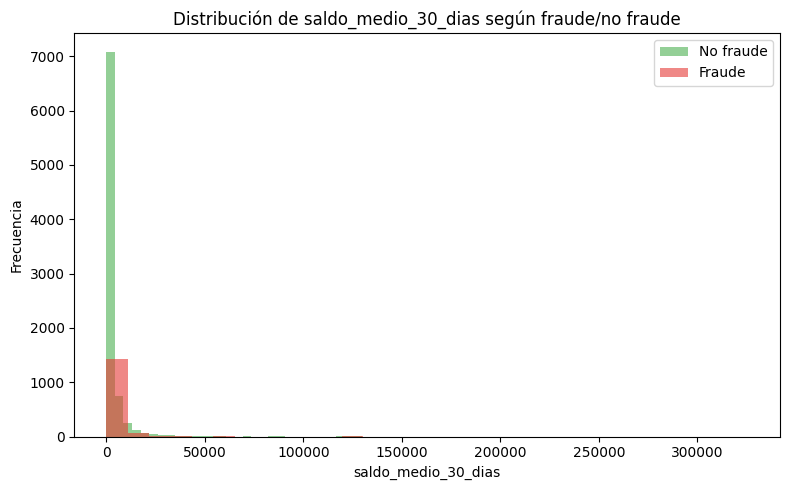

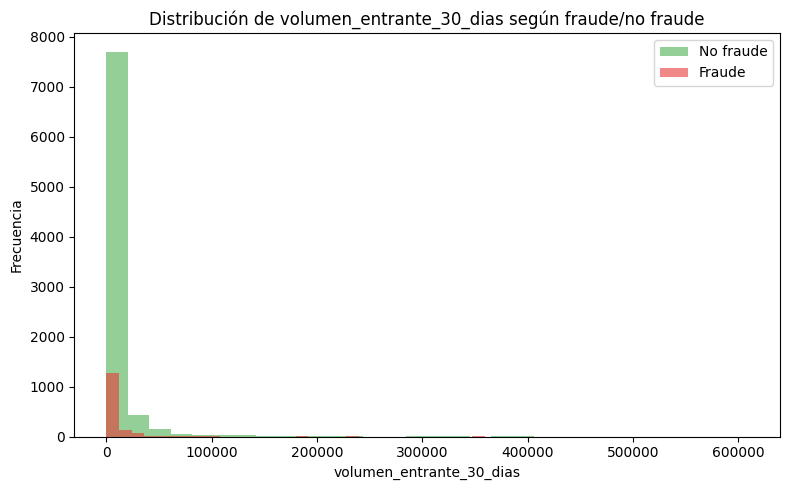

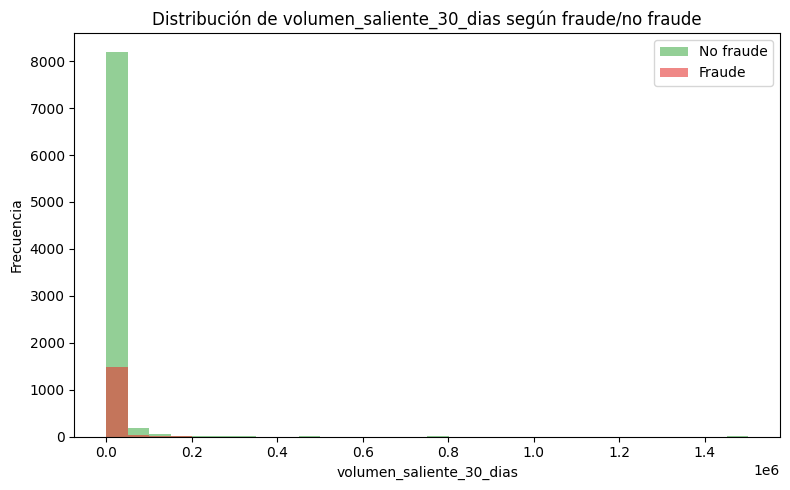

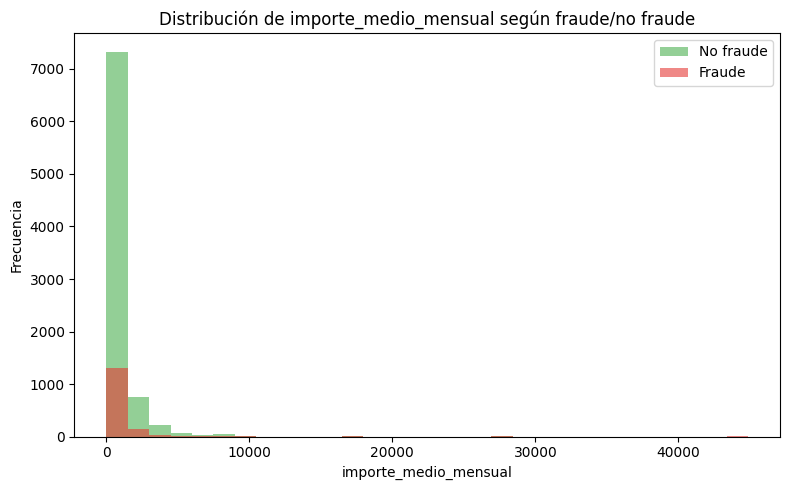

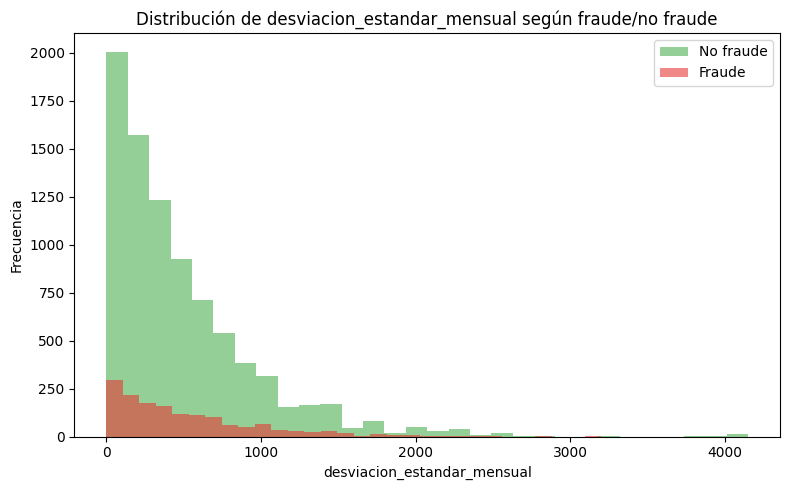

In [13]:
# Distribuciones de las variables/saldo volumen
variables_saldo_volumen = [
    'saldo_actual',
    'saldo_medio_30_dias',
    'volumen_entrante_30_dias',
    'volumen_saliente_30_dias',
    'importe_medio_mensual',
    'desviacion_estandar_mensual'
]

for col in variables_saldo_volumen:
    plt.figure(figsize=(8, 5))

    plt.hist(
        df[df['IS_FRAUD'] == 0][col].dropna(),
        bins=30,
        alpha=0.6,
        label='No fraude',
        color='#4CAF50'
    )

    plt.hist(
        df[df['IS_FRAUD'] == 1][col].dropna(),
        bins=30,
        alpha=0.6,
        label='Fraude',
        color='#E53935'
    )

    plt.title(f'Distribución de {col} según fraude/no fraude')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.tight_layout()
    plt.show()

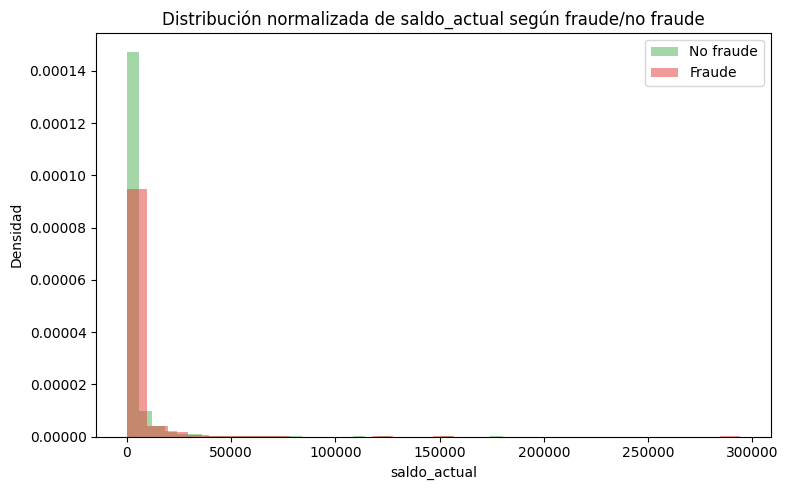

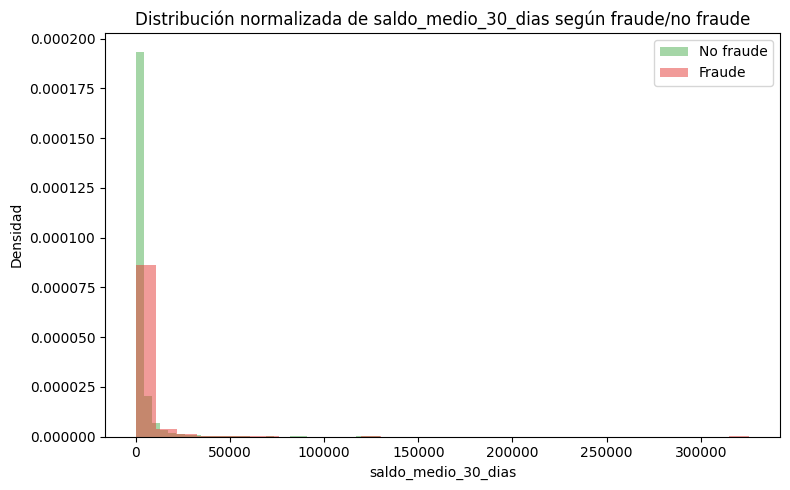

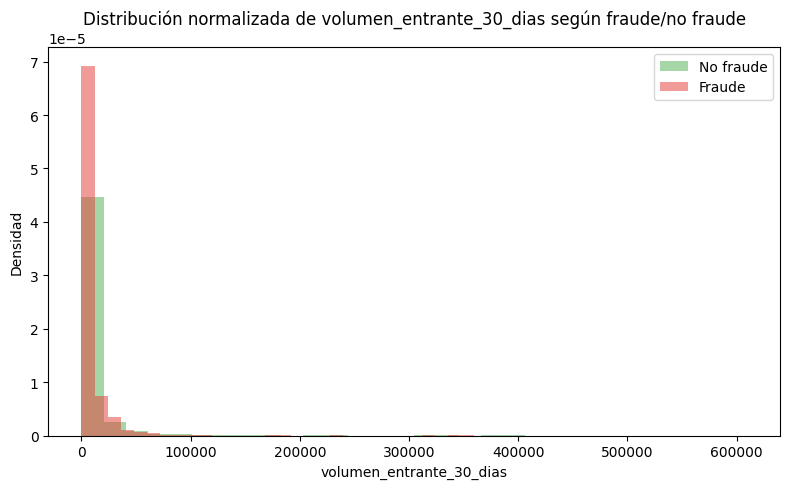

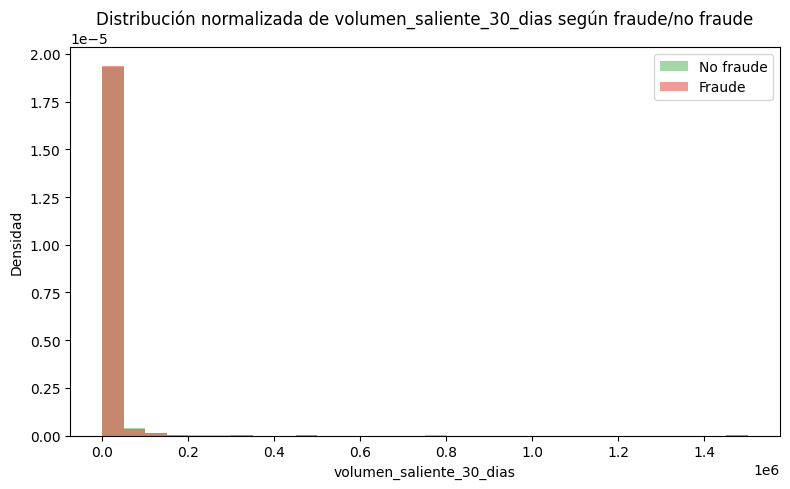

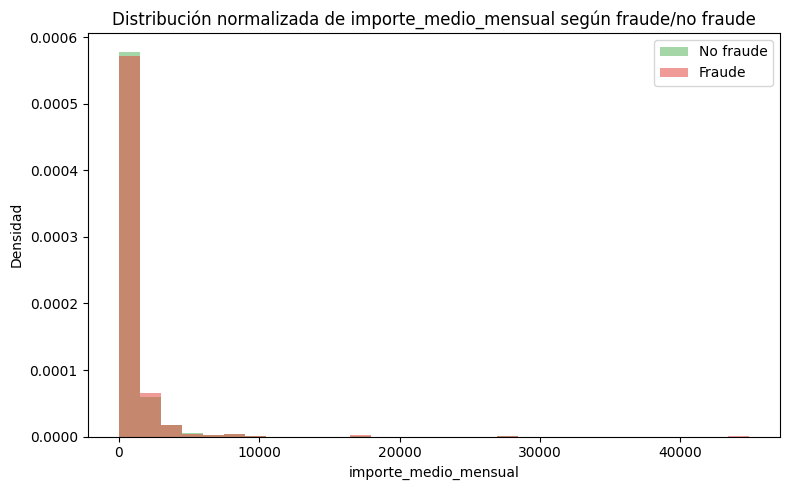

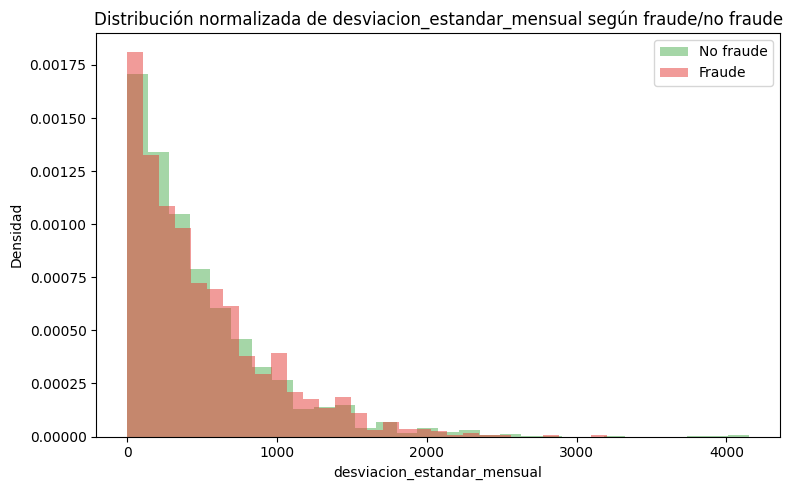

In [14]:
# Distribución normalizada variables saldo/volumen
variables_saldo_volumen = [
    'saldo_actual',
    'saldo_medio_30_dias',
    'volumen_entrante_30_dias',
    'volumen_saliente_30_dias',
    'importe_medio_mensual',
    'desviacion_estandar_mensual'
]

for col in variables_saldo_volumen:
    plt.figure(figsize=(8, 5))

    plt.hist(
        df[df['IS_FRAUD'] == 0][col].dropna(),
        bins=30,
        alpha=0.5,
        label='No fraude',
        color='#4CAF50',
        density=True
    )

    plt.hist(
        df[df['IS_FRAUD'] == 1][col].dropna(),
        bins=30,
        alpha=0.5,
        label='Fraude',
        color='#E53935',
        density=True
    )

    plt.title(f'Distribución normalizada de {col} según fraude/no fraude')
    plt.xlabel(col)
    plt.ylabel('Densidad')
    plt.legend()
    plt.tight_layout()
    plt.show()

> **Hallazgo 3.2 — Saldo y volumen:**  
> Todas las variables de saldo y volumen presentan fuerte sesgo a la derecha (cola larga). Las distribuciones entre clases (fraude/no fraude) son similares en términos de forma, aunque las transacciones fraudulentas tienden a concentrarse en importes intermedios-altos. Estas variables se beneficiarán de transformaciones logarítmicas o de estandarización robusta antes del modelado.

### 3.3 Antigüedad de cuenta y tarjeta

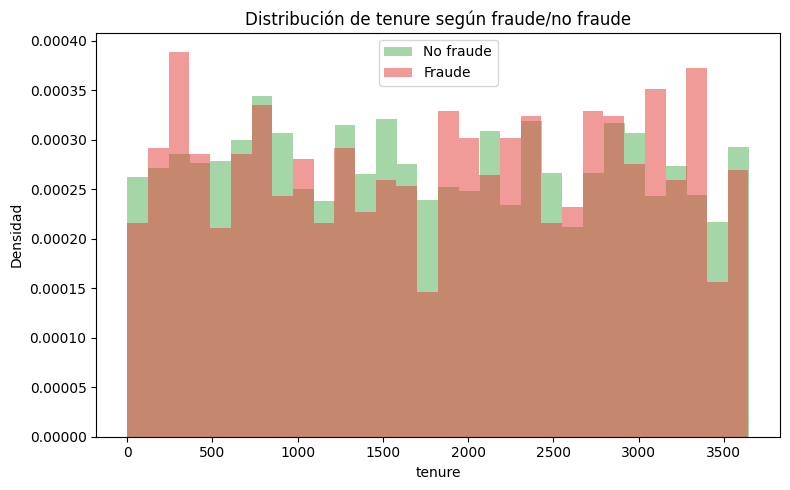

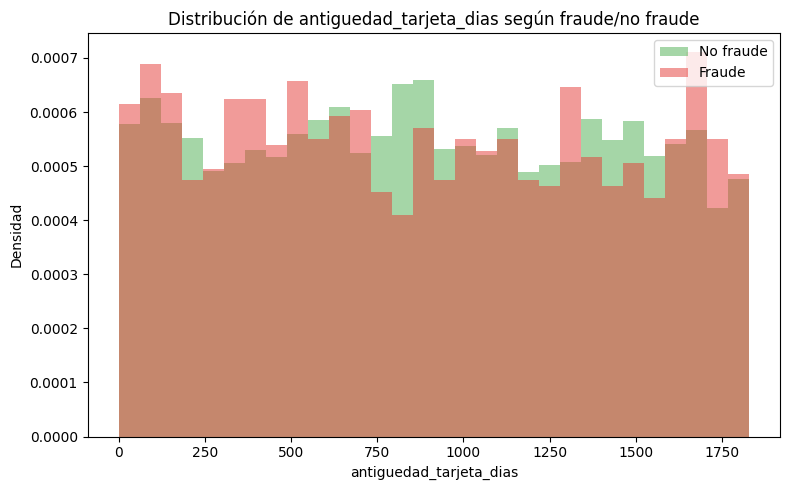

In [15]:
# Antigüedad cuenta x tarjeta
variables_antiguedad = [
    'tenure',
    'antiguedad_tarjeta_dias'
]

for col in variables_antiguedad:
    plt.figure(figsize=(8, 5))

    plt.hist(
        df[df['IS_FRAUD'] == 0][col].dropna(),
        bins=30,
        alpha=0.5,
        label='No fraude',
        color='#4CAF50',
        density=True
    )

    plt.hist(
        df[df['IS_FRAUD'] == 1][col].dropna(),
        bins=30,
        alpha=0.5,
        label='Fraude',
        color='#E53935',
        density=True
    )

    plt.title(f'Distribución de {col} según fraude/no fraude')
    plt.xlabel(col)
    plt.ylabel('Densidad')
    plt.legend()
    plt.tight_layout()
    plt.show()

> **Hallazgo 3.3 — Antigüedad de cuenta y tarjeta:**  
> Tanto `tenure` (antigüedad de la cuenta en días) como `antiguedad_tarjeta_dias` muestran distribuciones amplias. No se aprecia un patrón visual claro que concentre el fraude en cuentas o tarjetas recién creadas, aunque la señal podría ser sutil. Ambas variables se analizarán en la fase bivariante; si no aportan señal individual, pueden combinarse con otras (p.ej. ratio tenure/importe).

### 3.4 Tiempo desde la última transacción

La unidad original es segundos. Convertimos a minutos, horas y días
para facilitar la interpretación, y analizamos el fraud rate por tramo.

In [16]:
# Tiempo desde la ult transaccion
df['tiempo_desde_ultima_min'] = df['tiempo_desde_ultima_transaccion'] / 60
df['tiempo_desde_ultima_horas'] = df['tiempo_desde_ultima_transaccion'] / 3600
df['tiempo_desde_ultima_dias'] = df['tiempo_desde_ultima_transaccion'] / 86400

display(df['tiempo_desde_ultima_transaccion'].describe())
display(df['tiempo_desde_ultima_min'].describe())
display(df['tiempo_desde_ultima_horas'].describe())
display(df['tiempo_desde_ultima_dias'].describe())

count    1.000000e+04
mean     1.360110e+06
std      2.956285e+06
min      0.000000e+00
25%      0.000000e+00
50%      4.361600e+04
75%      1.579065e+05
max      1.542519e+07
Name: tiempo_desde_ultima_transaccion, dtype: float64

count     10000.000000
mean      22668.497470
std       49271.410323
min           0.000000
25%           0.000000
50%         726.933333
75%        2631.775000
max      257086.566667
Name: tiempo_desde_ultima_min, dtype: float64

count    10000.000000
mean       377.808291
std        821.190172
min          0.000000
25%          0.000000
50%         12.115556
75%         43.862917
max       4284.776111
Name: tiempo_desde_ultima_horas, dtype: float64

count    10000.000000
mean        15.742012
std         34.216257
min          0.000000
25%          0.000000
50%          0.504815
75%          1.827622
max        178.532338
Name: tiempo_desde_ultima_dias, dtype: float64

In [17]:
# Representacion numerica tiempo ult transaccion
bins = [-1, 0, 10, 30, 60, 300, 1800, 7200, 86400, df['tiempo_desde_ultima_transaccion'].max()]
labels = ['0 s', '1-10 s', '10-30 s', '30-60 s', '1-5 min', '5-30 min', '30 min-2 h', '2-24 h', '>24 h']

df['tramo_tiempo_ultima_tx'] = pd.cut(
    df['tiempo_desde_ultima_transaccion'],
    bins=bins,
    labels=labels
)

resumen_tiempo = (
    df.groupby('tramo_tiempo_ultima_tx', observed=False)['IS_FRAUD']
    .agg(
        total='size',
        fraud_rate='mean'
    )
    .reset_index()
)

display(resumen_tiempo)

,tramo_tiempo_ultima_tx,total,fraud_rate
0,0 s,2571,0.152859
1,1-10 s,0,NaN
2,10-30 s,0,NaN
3,30-60 s,0,NaN
4,1-5 min,0,NaN
5,5-30 min,0,NaN
6,30 min-2 h,204,0.112745
7,2-24 h,4703,0.147140
8,>24 h,2522,0.165741


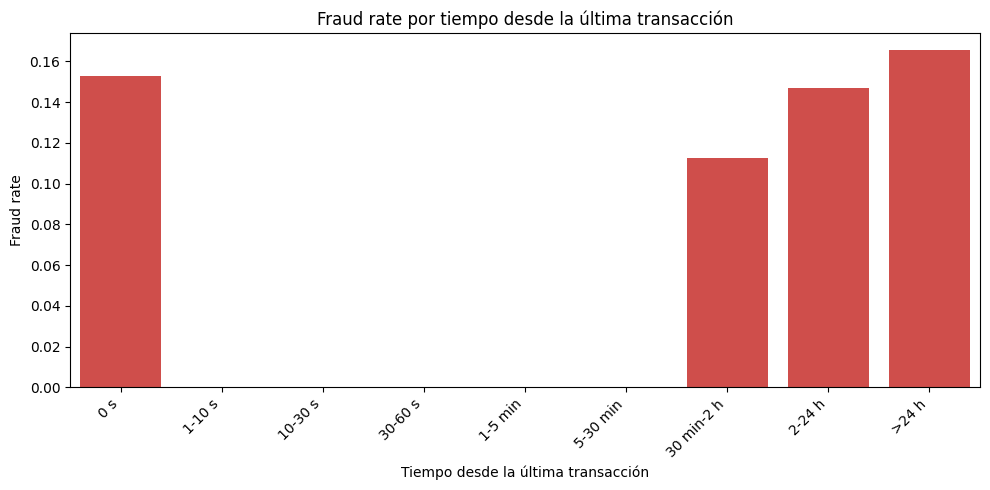

In [18]:
# Representacion visual tiempo ult transaccion
plt.figure(figsize=(10, 5))
sns.barplot(
    data=resumen_tiempo,
    x='tramo_tiempo_ultima_tx',
    y='fraud_rate',
    color='#E53935'
)
plt.title('Fraud rate por tiempo desde la última transacción')
plt.xlabel('Tiempo desde la última transacción')
plt.ylabel('Fraud rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> **Hallazgo 3.4 — Tiempo desde la última transacción:**  
> La variable está en segundos (max ~15M seg ≈ 174 días). Se observan dos patrones interesantes: transacciones muy rápidas (< 1 min desde la anterior) con fraud rate ligeramente elevado, y transacciones muy espaciadas en el tiempo también con mayor fraude. El tramo 1–10 min parece el de menor riesgo. La velocidad de transacción es un feature candidato relevante para el modelo.

### 3.5 Outliers en variables continuas

Analizamos las variables con colas largas mediante boxplots y la tabla IQR.
Repetimos en escala logarítmica para visualizar la estructura sin el efecto de los extremos.

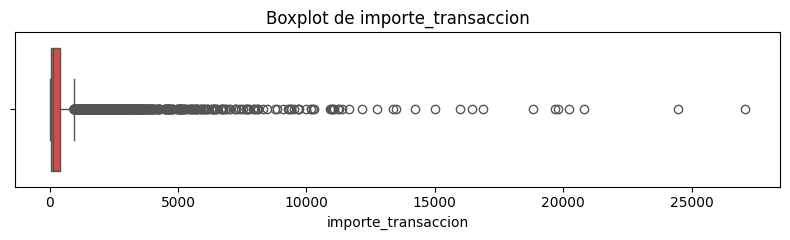

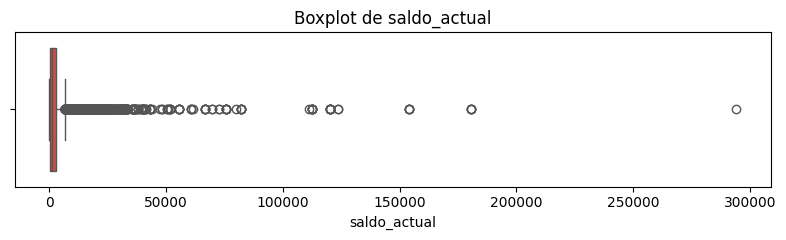

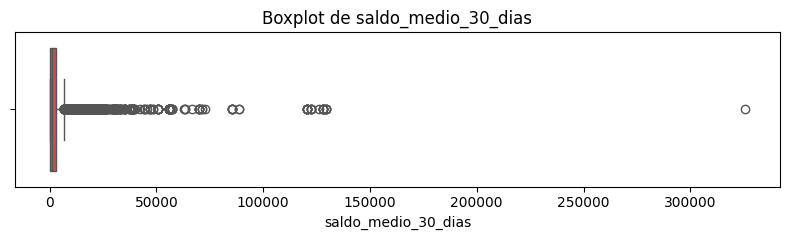

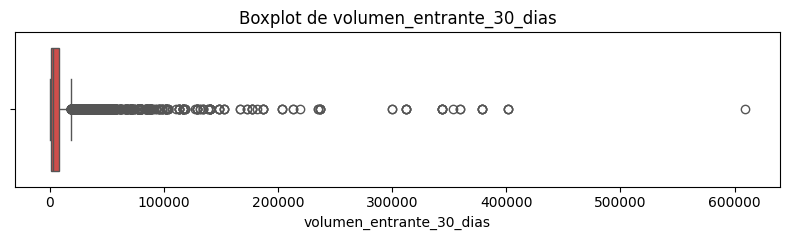

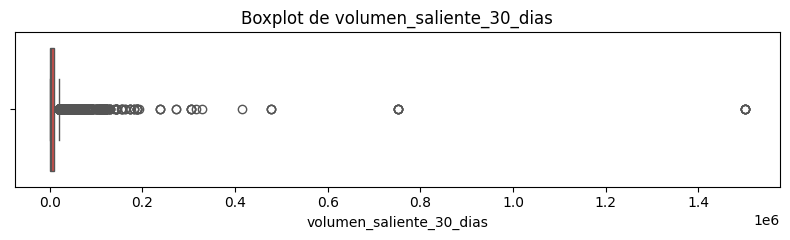

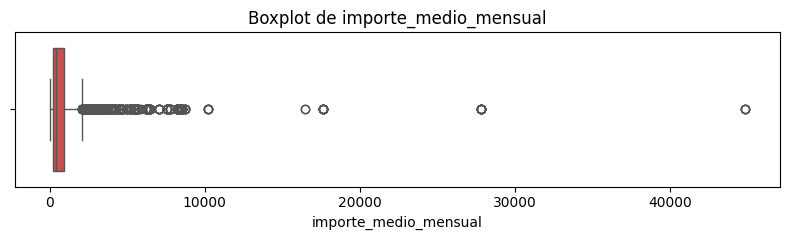

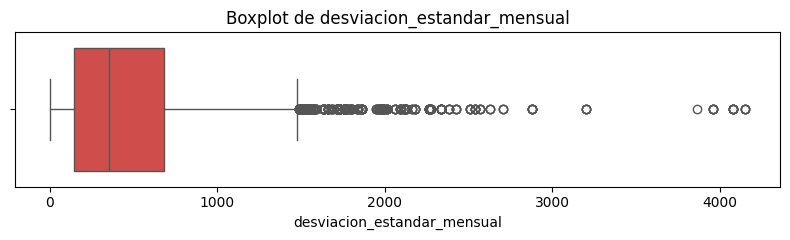

In [19]:
# Outliers en numericas continuas
variables_outliers = [
    'importe_transaccion',
    'saldo_actual',
    'saldo_medio_30_dias',
    'volumen_entrante_30_dias',
    'volumen_saliente_30_dias',
    'importe_medio_mensual',
    'desviacion_estandar_mensual'
]

for col in variables_outliers:
    plt.figure(figsize=(8, 2.5))
    sns.boxplot(x=df[col], color='#E53935')
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [20]:
# Tabla IQR
resumen_outliers = []

for col in variables_outliers:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_outliers = n_outliers / len(df) * 100

    resumen_outliers.append({
        'variable': col,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'limite_inferior': lower,
        'limite_superior': upper,
        'n_outliers': n_outliers,
        'pct_outliers': pct_outliers
    })

resumen_outliers = pd.DataFrame(resumen_outliers).sort_values('pct_outliers', ascending=False)
display(resumen_outliers)

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,pct_outliers
0,importe_transaccion,54.3825,409.7475,355.3650,-478.66500,942.79500,1206,12.06
4,volumen_saliente_30_dias,1132.0225,8401.3725,7269.3500,-9772.00250,19305.39750,1095,10.95
1,saldo_actual,401.2100,2928.1275,2526.9175,-3389.16625,6718.50375,1030,10.30
2,saldo_medio_30_dias,387.9700,2911.2900,2523.3200,-3397.01000,6696.27000,1024,10.24
3,volumen_entrante_30_dias,1094.7775,8159.3350,7064.5575,-9502.05875,18756.17125,1024,10.24
5,importe_medio_mensual,192.3800,956.2300,763.8500,-953.39500,2102.00500,800,8.00
6,desviacion_estandar_mensual,147.0200,681.0300,534.0100,-653.99500,1482.04500,407,4.07


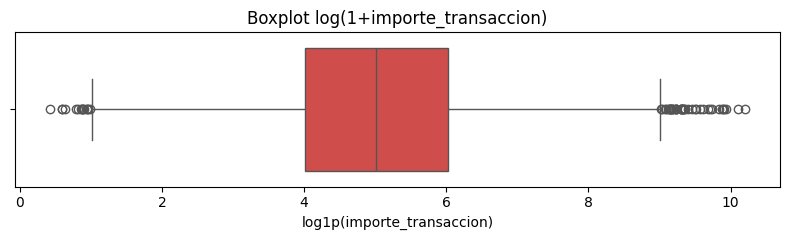

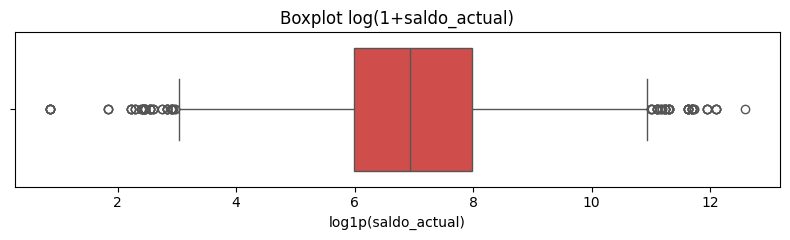

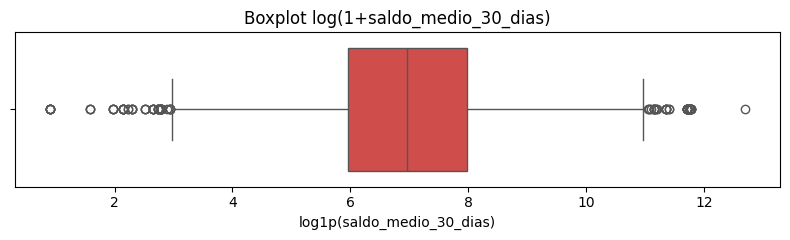

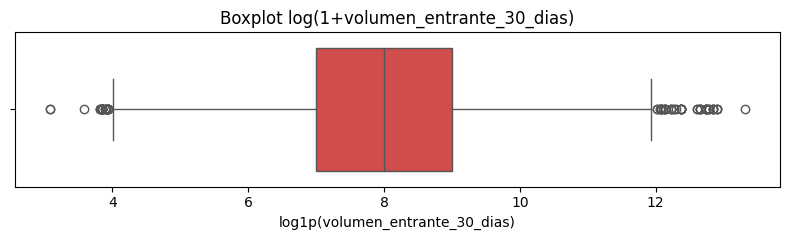

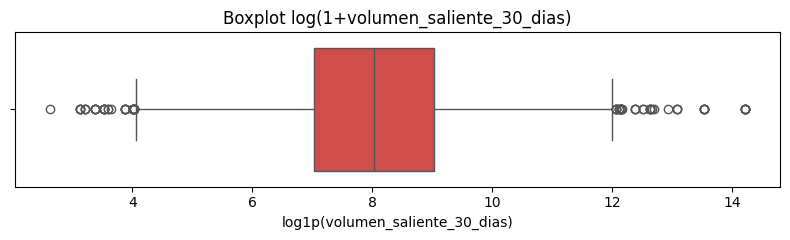

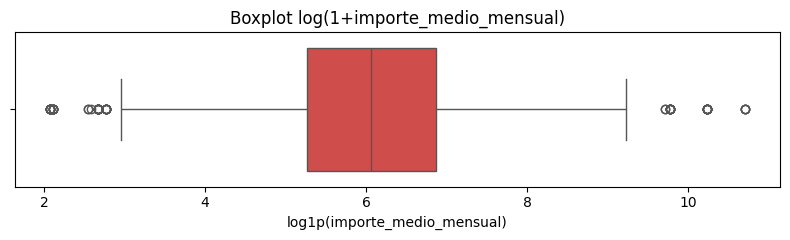

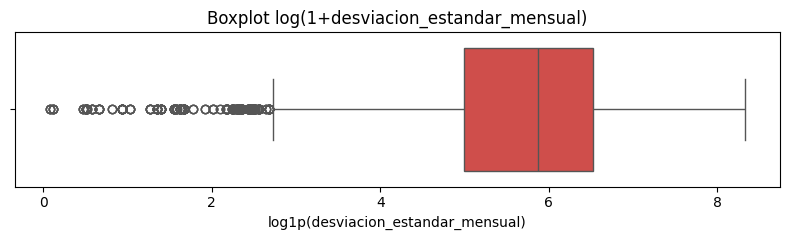

In [21]:
# Boxplot logaritmo
for col in variables_outliers:
    plt.figure(figsize=(8, 2.5))
    sns.boxplot(x=np.log1p(df[col]), color='#E53935')
    plt.title(f'Boxplot log(1+{col})')
    plt.xlabel(f'log1p({col})')
    plt.tight_layout()
    plt.show()

> **Hallazgo 3.5 — Outliers:**  
> Las variables de importe y volumen presentan outliers extremos (valores hasta 10–100x la mediana). Estos outliers **no son errores** — en fraude, las transacciones anómalas son precisamente la señal. Se documentan para tenerlos en cuenta al escalar (usar `RobustScaler` en lugar de `StandardScaler`) y al interpretar modelos basados en distancias.

## 4. Análisis bivariante — Temporalidad y variables categóricas

Analizamos cómo se distribuye el fraude en función del tiempo
y de las variables categóricas clave.

### 4.1 Fraud rate por franja temporal

In [22]:
# Calculamos la proporción de fraude (fraud rate) por hora, día de la semana y mes
fraud_rate_hora = (
    df.groupby('hora')['IS_FRAUD']
    .mean()
    .reset_index(name='fraud_rate')
)

fraud_rate_dia_semana = (
    df.groupby('dia_semana')['IS_FRAUD']
    .mean()
    .reset_index(name='fraud_rate')
)

orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fraud_rate_dia_semana['dia_semana'] = pd.Categorical(
    fraud_rate_dia_semana['dia_semana'],
    categories=orden_dias,
    ordered=True
)
fraud_rate_dia_semana = fraud_rate_dia_semana.sort_values('dia_semana')

fraud_rate_mes = (
    df.groupby('mes')['IS_FRAUD']
    .mean()
    .reset_index(name='fraud_rate')
)

print("Fraud rate por hora")
display(fraud_rate_hora)

print("Fraud rate por día de la semana")
display(fraud_rate_dia_semana)

# El dataset no comprende un año completo, los meses que faltan son porque no tenemos transacciones de esas fechas en nuestro dataset.
print("Fraud rate por mes")
display(fraud_rate_mes)

Fraud rate por hora


,hora,fraud_rate
0,0,0.154930
1,1,0.133995
2,2,0.200466
3,3,0.158621
4,4,0.147343
5,5,0.155606
6,6,0.141204
7,7,0.153659
8,8,0.146512
9,9,0.114058


Fraud rate por día de la semana


,dia_semana,fraud_rate
1,Monday,0.154225
5,Tuesday,0.155680
6,Wednesday,0.152086
4,Thursday,0.159187
0,Friday,0.150107
2,Saturday,0.157153
3,Sunday,0.139747


Fraud rate por mes


,mes,fraud_rate
0,1,0.160494
1,2,0.148990
2,3,0.165143
3,4,0.147531
4,5,0.150087
5,11,0.120690
6,12,0.152824


> **Hallazgo 4.1 — Temporalidad:**  
> El fraude no muestra un patrón temporal nítido: la fraud rate se mantiene estable entre el 14–16% en casi todas las horas y días. Los picos en **hora 2 y hora 12** (~20%) son estadísticamente modestos. Esto sugiere que las variables temporales (`hora`, `dia_semana`, `mes`) tienen capacidad predictiva limitada en solitario — su valor puede estar en combinaciones con otras variables (ver heatmaps).

### 4.2 Distribución de fraude por variable categórica y temporal

Comparamos el volumen absoluto de transacciones fraudulentas vs legítimas en cada categoría.

Columnas encontradas: ['tipo_cliente', 'customer_country', 'customer_region', 'estado_cuenta', 'estado_tarjeta', 'tipo_transaccion', 'metodo_autenticacion', 'operacion_pais', 'operacion_region', 'dia_semana', 'hora', 'mes']
Columnas no encontradas: []


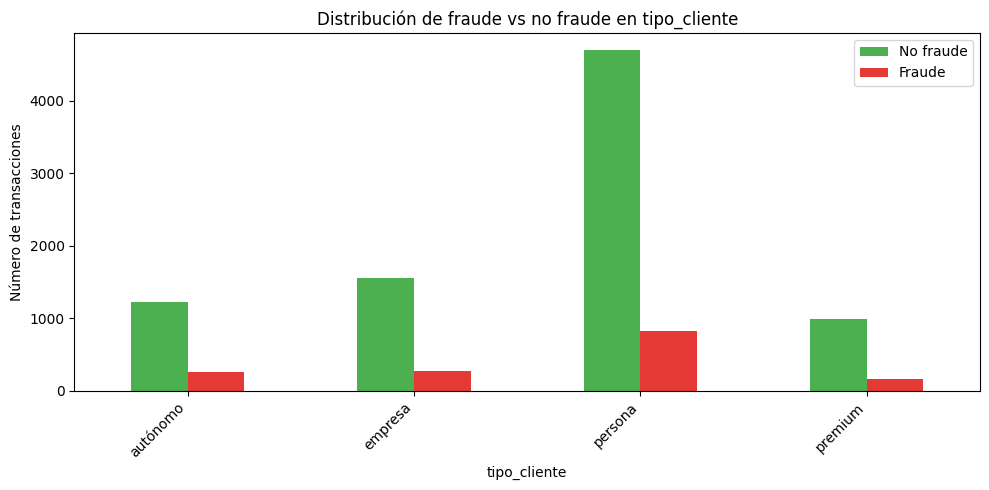

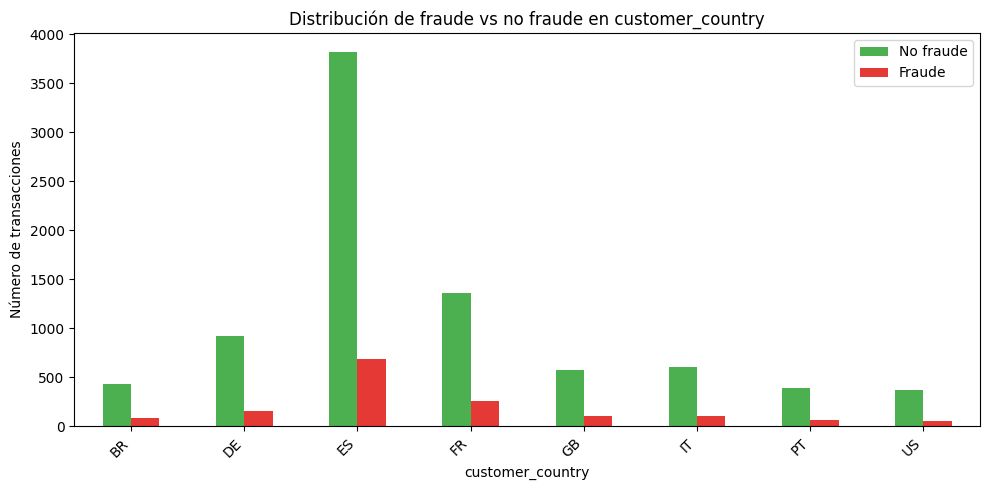

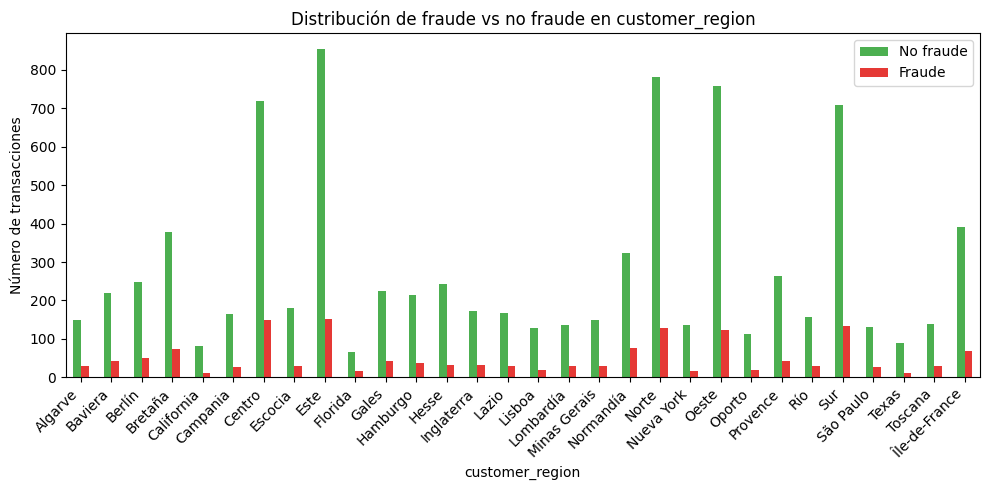

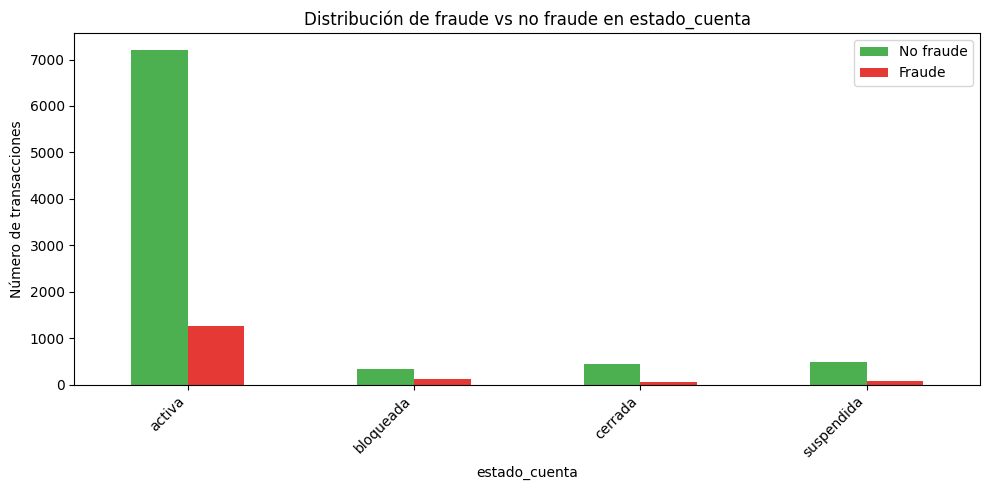

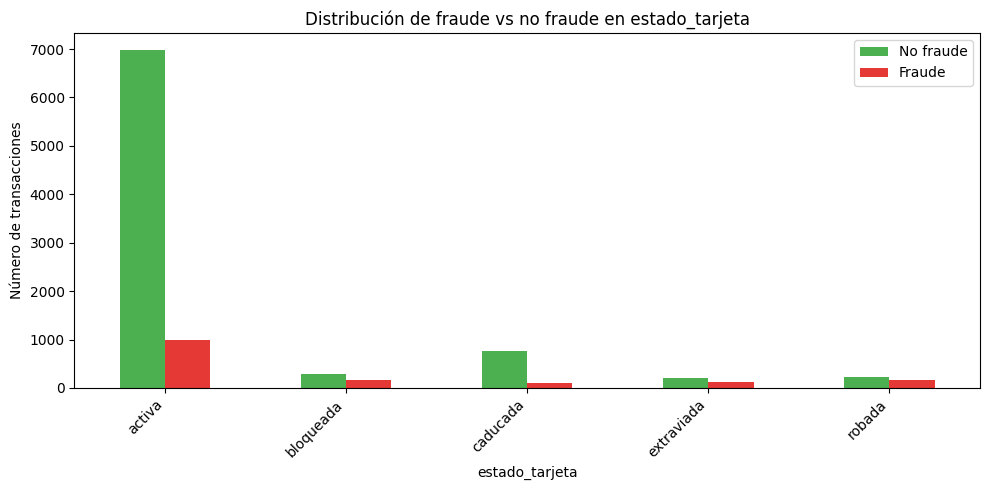

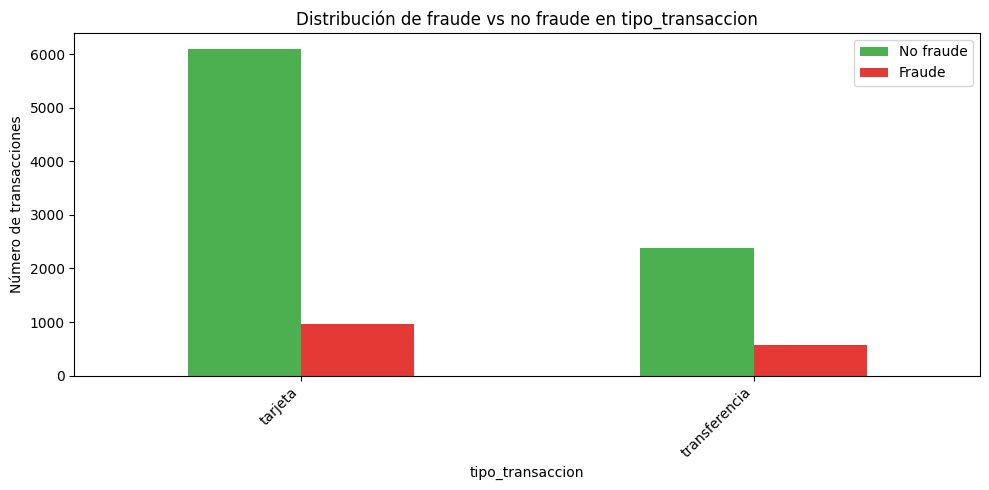

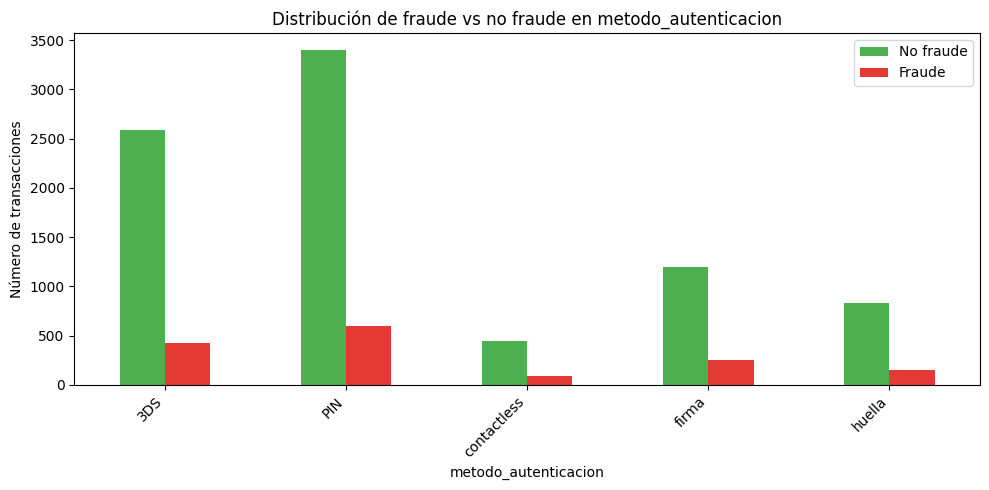

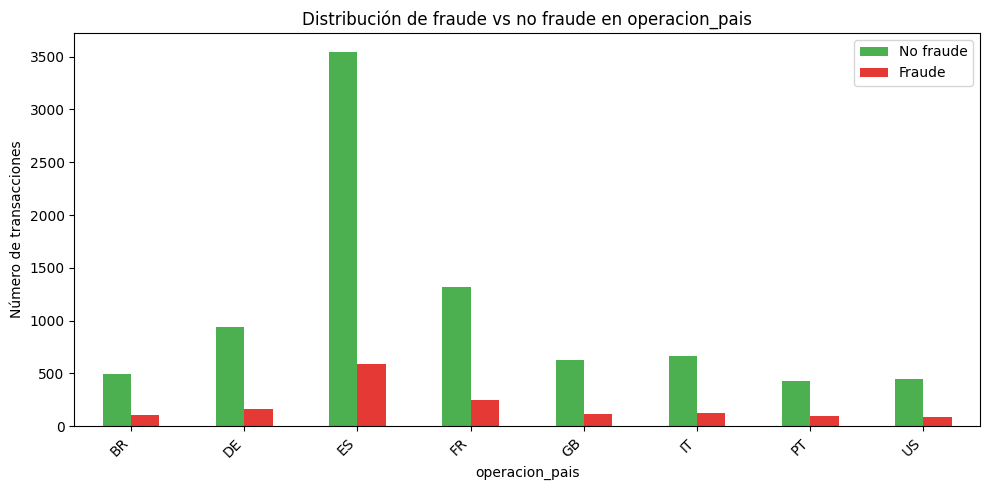

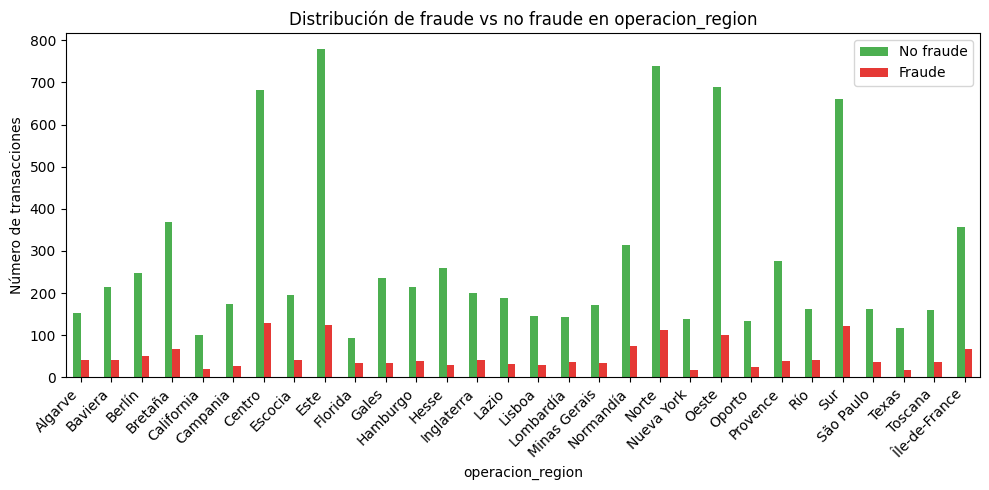

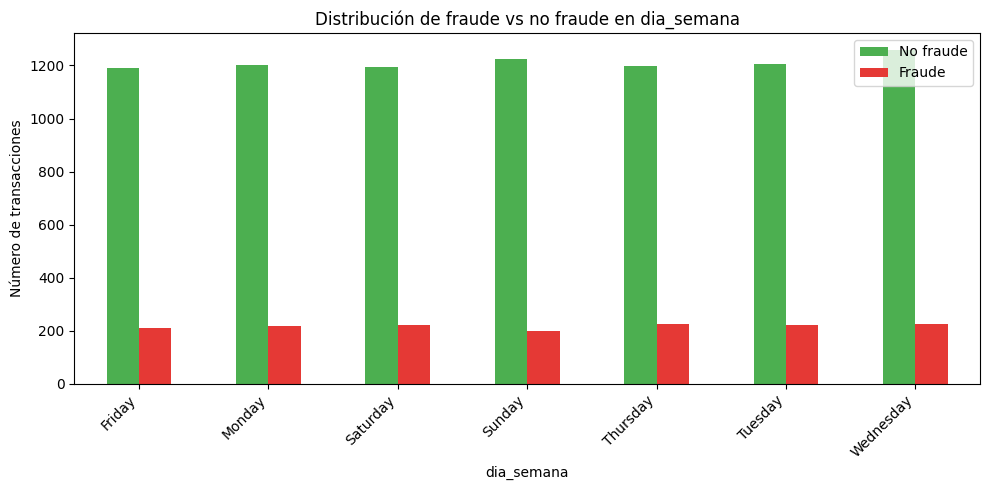

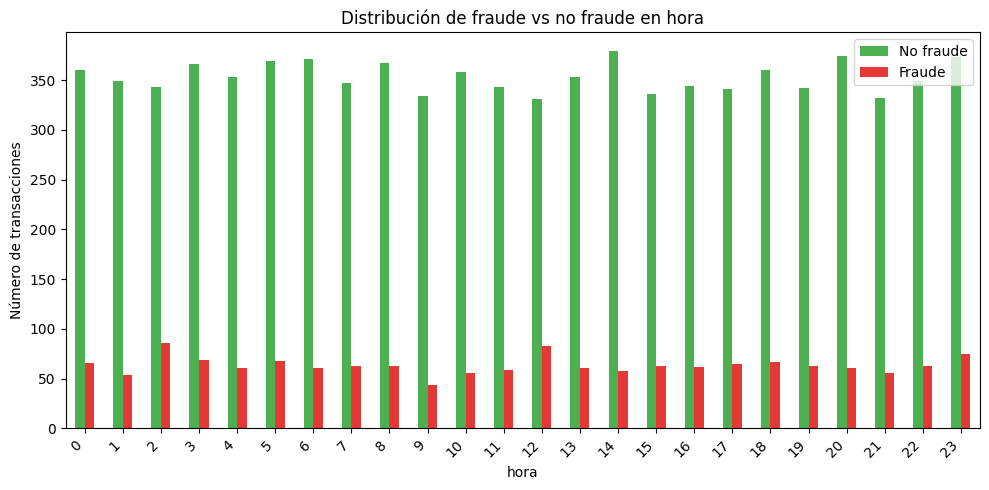

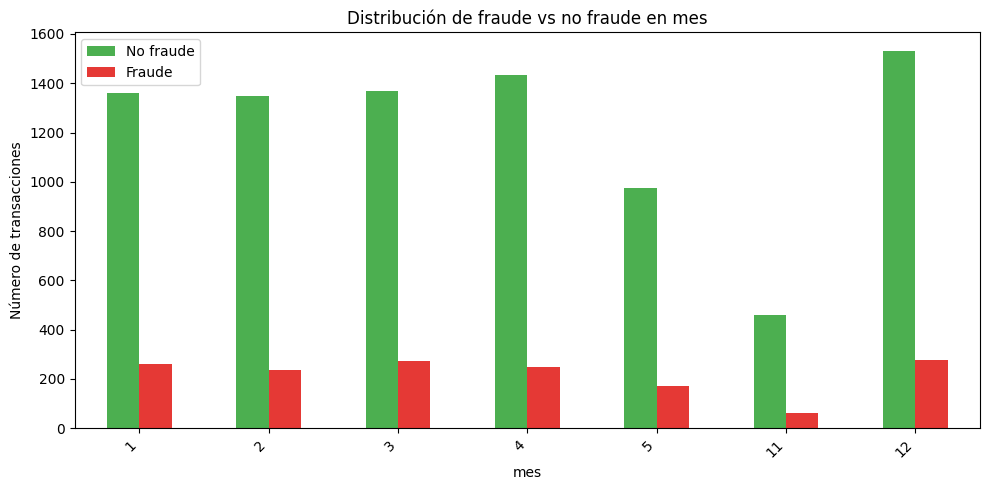

In [23]:
cols_to_plot = [
    'tipo_cliente',
    'customer_country',
    'customer_region',
    'estado_cuenta',
    'estado_tarjeta',
    'tipo_transaccion',
    'metodo_autenticacion',
    'operacion_pais',
    'operacion_region',
    'dia_semana',
    'hora',
    'mes'
]

cols_existentes = [col for col in cols_to_plot if col in df.columns]
cols_faltantes = [col for col in cols_to_plot if col not in df.columns]

print('Columnas encontradas:', cols_existentes)
print('Columnas no encontradas:', cols_faltantes)

for col in cols_existentes:
    tabla = pd.crosstab(df[col], df['IS_FRAUD'])
    tabla = tabla.reindex(columns=[0, 1], fill_value=0)
    tabla.columns = ['No fraude', 'Fraude']

    tabla.plot(kind='bar', figsize=(10, 5), color=['#4CAF50', '#E53935'])
    plt.title(f'Distribución de fraude vs no fraude en {col}')
    plt.xlabel(col)
    plt.ylabel('Número de transacciones')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

> **Hallazgo 4.2 — Variables categóricas:**  
> `estado_tarjeta` muestra diferencias claras entre categorías (tarjetas bloqueadas o expiradas concentran más fraude). `tipo_transaccion` y `metodo_autenticacion` también presentan diferencias apreciables. Variables geográficas como `customer_country` y `operacion_pais` muestran poca variación entre clases en términos de fraud rate global, aunque el análisis cross-border puede revelar más.

### 4.3 Heatmaps de fraud rate — Temporalidad cruzada con otras variables

Buscamos si hay combinaciones hora/día, hora/importe, etc. que concentren más fraude.

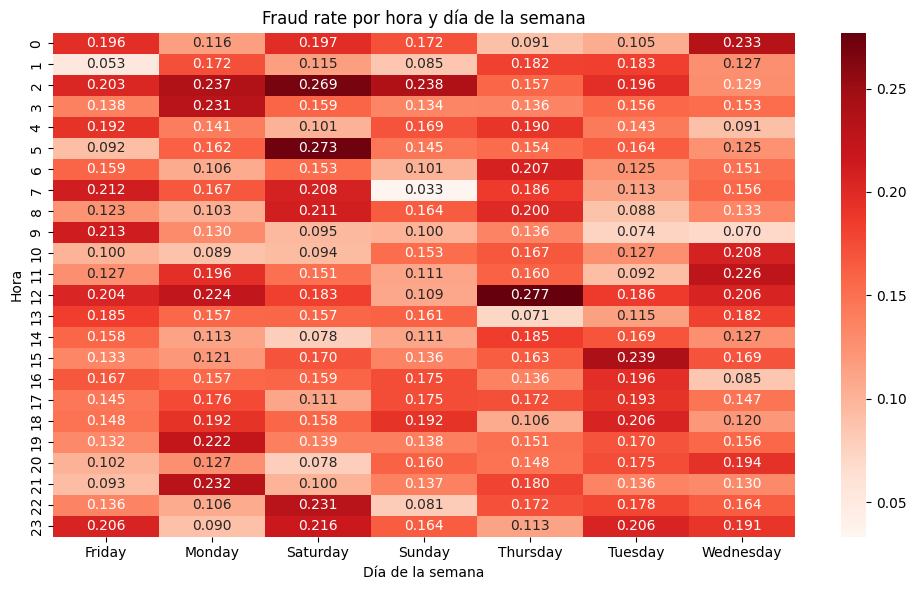

In [24]:
# Heatmap: fraud rate por hora × día de la semana
pivot = df.pivot_table(
    values='IS_FRAUD',
    index='hora',
    columns='dia_semana',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, cmap='Reds', annot=True, fmt='.3f')
plt.title('Fraud rate por hora y día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Hora')
plt.tight_layout()
plt.show()

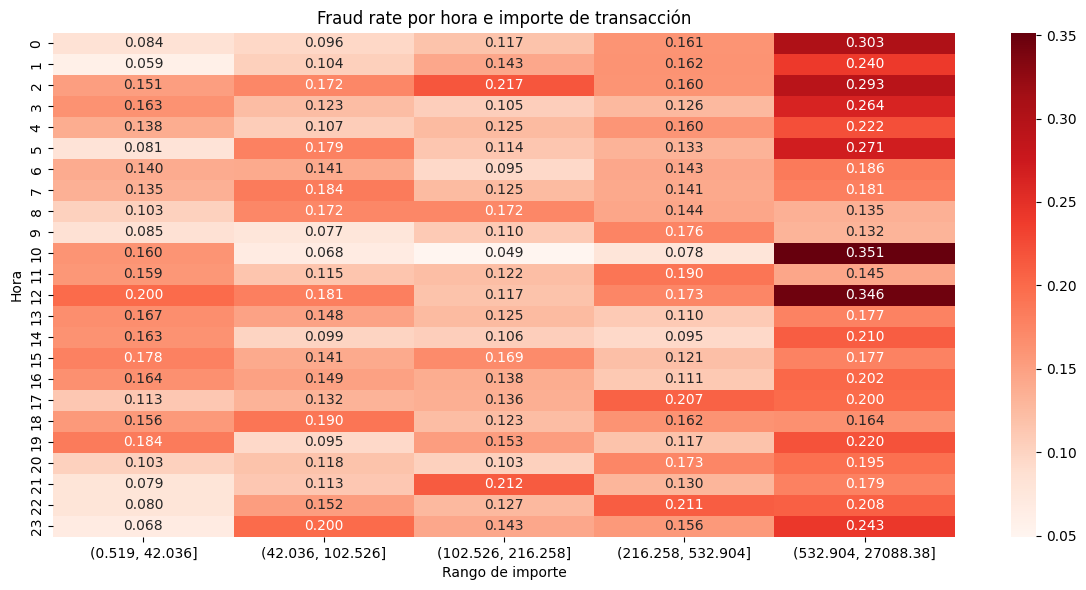

In [25]:
# Creamos tramos de importe por quintiles y cruzamos con hora
df['importe_bin'] = pd.qcut(df['importe_transaccion'], q=5, duplicates='drop')

pivot_hora_importe = df.pivot_table(
    values='IS_FRAUD',
    index='hora',
    columns='importe_bin',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_hora_importe, cmap='Reds', annot=True, fmt='.3f')
plt.title('Fraud rate por hora e importe de transacción')
plt.xlabel('Rango de importe')
plt.ylabel('Hora')
plt.tight_layout()
plt.show()

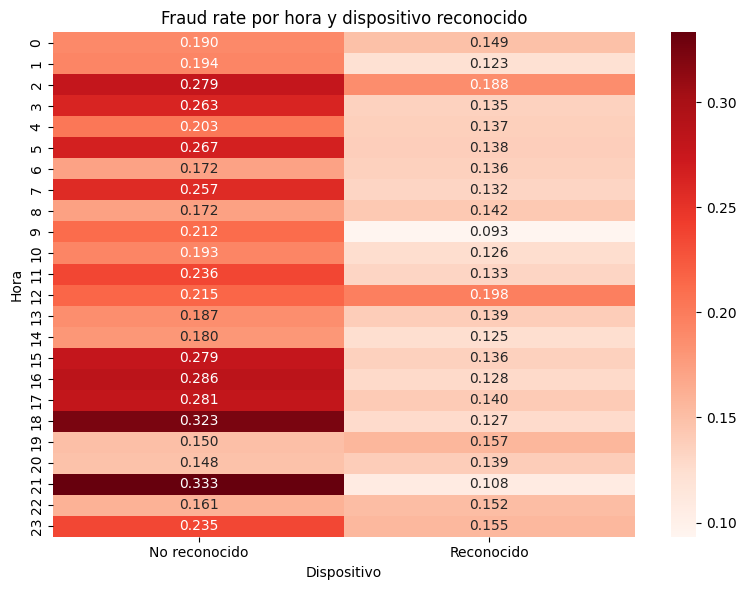

In [26]:
# Heatmap: fraud rate por hora × dispositivo reconocido
df['dispositivo_label'] = df['dispositivo_reconocido'].map({
    0: 'No reconocido',
    1: 'Reconocido'
})

pivot_hora_dispositivo = df.pivot_table(
    values='IS_FRAUD',
    index='hora',
    columns='dispositivo_label',
    aggfunc='mean'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_hora_dispositivo, cmap='Reds', annot=True, fmt='.3f')
plt.title('Fraud rate por hora y dispositivo reconocido')
plt.xlabel('Dispositivo')
plt.ylabel('Hora')
plt.tight_layout()
plt.show()

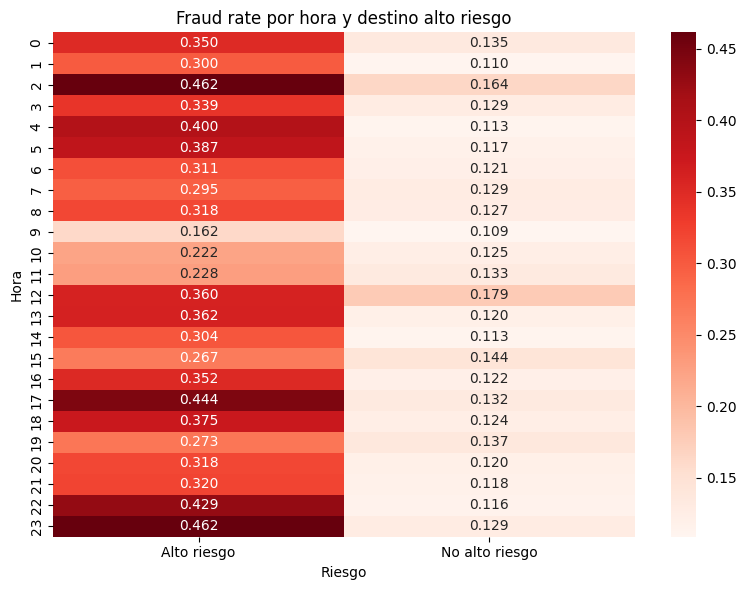

In [27]:
# Heatmap: fraud rate por hora × destino de alto riesgo
df['riesgo_label'] = df['destino_alto_riesgo'].map({
    0: 'No alto riesgo',
    1: 'Alto riesgo'
})

pivot_hora_riesgo = df.pivot_table(
    values='IS_FRAUD',
    index='hora',
    columns='riesgo_label',
    aggfunc='mean'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_hora_riesgo, cmap='Reds', annot=True, fmt='.3f')
plt.title('Fraud rate por hora y destino alto riesgo')
plt.xlabel('Riesgo')
plt.ylabel('Hora')
plt.tight_layout()
plt.show()

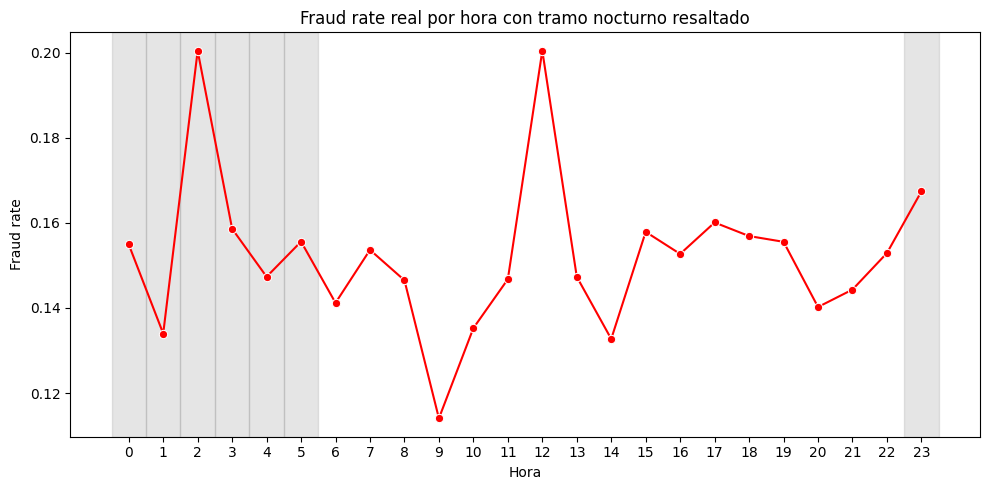

In [28]:
# Línea de fraud rate por hora — zona gris = franja nocturna (is_night)
# Lo resaltado = franja is_night
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=fraud_rate_hora,
    x='hora',
    y='fraud_rate',
    marker='o',
    color='red'
)

for h in [23, 0, 1, 2, 3, 4, 5]:
    plt.axvspan(h - 0.5, h + 0.5, color='gray', alpha=0.2)

plt.title('Fraud rate real por hora con tramo nocturno resaltado')
plt.xlabel('Hora')
plt.ylabel('Fraud rate')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

> **Hallazgo 4.3 — Heatmaps temporales cruzados:**  
> Los cruces más informativos son **dispositivo no reconocido** (~21–30% de fraud rate frente a ~12% para reconocidos) y **destino alto riesgo** (que multiplica el fraude en cualquier franja horaria). El importe alto también eleva la tasa, especialmente fuera del horario nocturno. El cruce hora × día de la semana confirma que no hay patrón temporal dominante.

### 4.4 Análisis cross-border

Comprobamos si las operaciones realizadas desde un país diferente al del cliente
tienen un fraud rate mayor.

In [29]:
# Analisis crossborder
df['pais_distinto'] = df['customer_country'] != df['operacion_pais']

resumen_cross_border = (
    df.groupby('pais_distinto')['IS_FRAUD']
    .agg(
        total='size',
        fraud_rate='mean'
    )
    .reset_index()
)

resumen_cross_border['pais_distinto'] = resumen_cross_border['pais_distinto'].map({
    False: 'Mismo país',
    True: 'País distinto'
})

display(resumen_cross_border)

,pais_distinto,total,fraud_rate
0,Mismo país,8997,0.139824
1,País distinto,1003,0.267198


C:\Users\juan_\AppData\Local\Temp\ipykernel_21400\1219786337.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


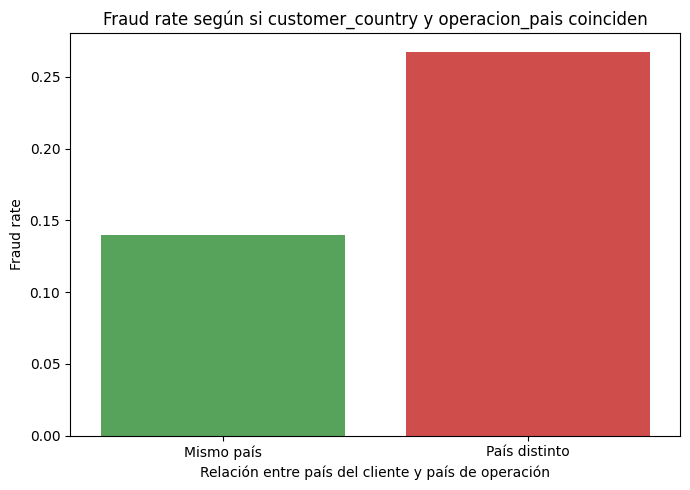

In [30]:
#Representacion visual analasisis crossborder
plt.figure(figsize=(7, 5))
sns.barplot(
    data=resumen_cross_border,
    x='pais_distinto',
    y='fraud_rate',
    palette=['#4CAF50', '#E53935']
)
plt.title('Fraud rate según si customer_country y operacion_pais coinciden')
plt.xlabel('Relación entre país del cliente y país de operación')
plt.ylabel('Fraud rate')
plt.tight_layout()
plt.show()

> **Hallazgo 4.4 — Análisis cross-border:**  
> Las transacciones en las que el país de operación difiere del país del cliente presentan una fraud rate significativamente más alta. Este **flag cross-border** (`operacion_pais != customer_country`) es uno de los features derivados más prometedores para el modelo — sencillo de construir y con señal clara.

## 5. Análisis bivariante — Variables numéricas vs `IS_FRAUD`

Comparamos la distribución de variables numéricas entre
transacciones fraudulentas y legítimas.

### 5.1 Histogramas comparados (fraude vs no fraude)

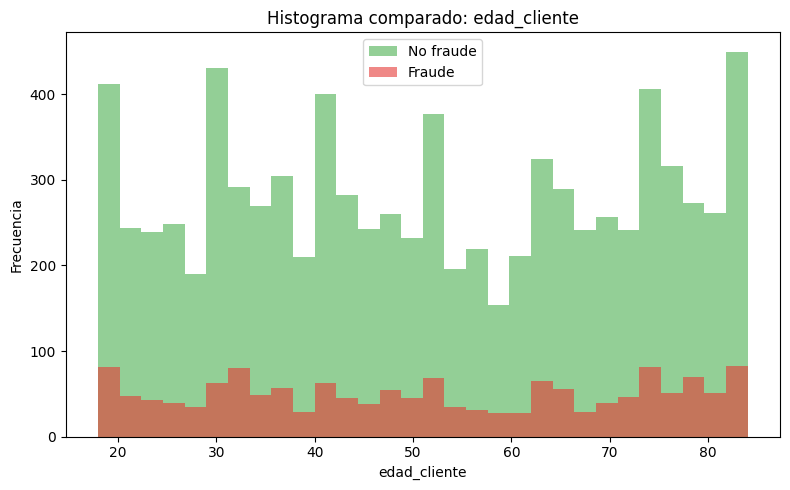

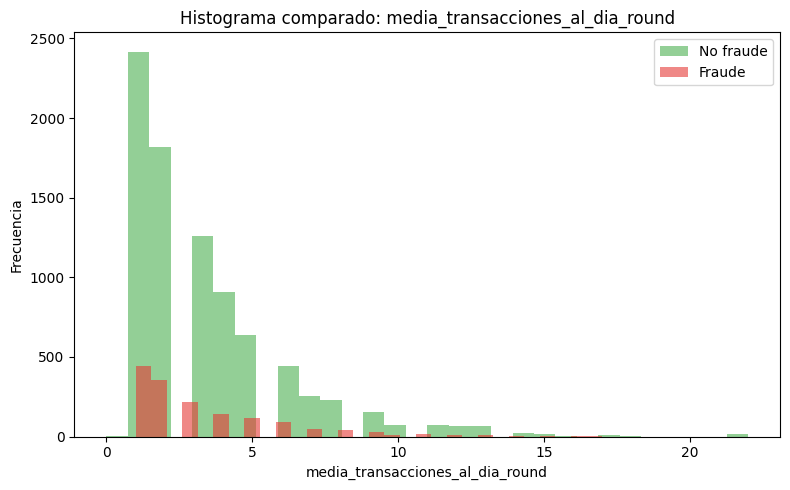

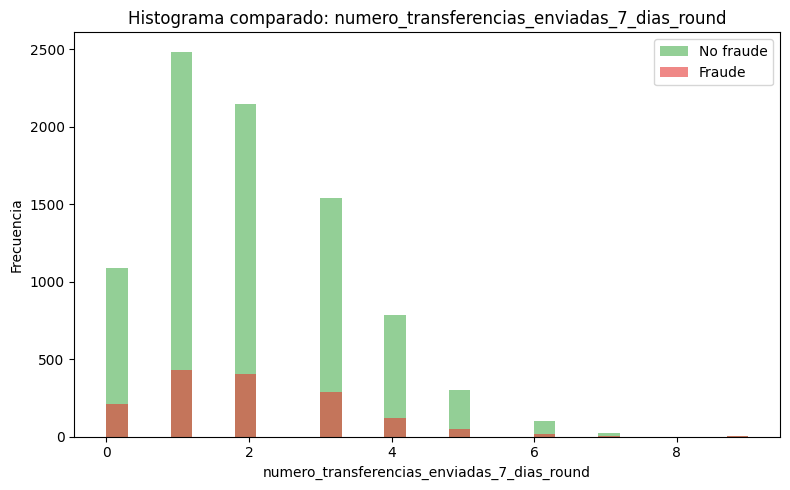

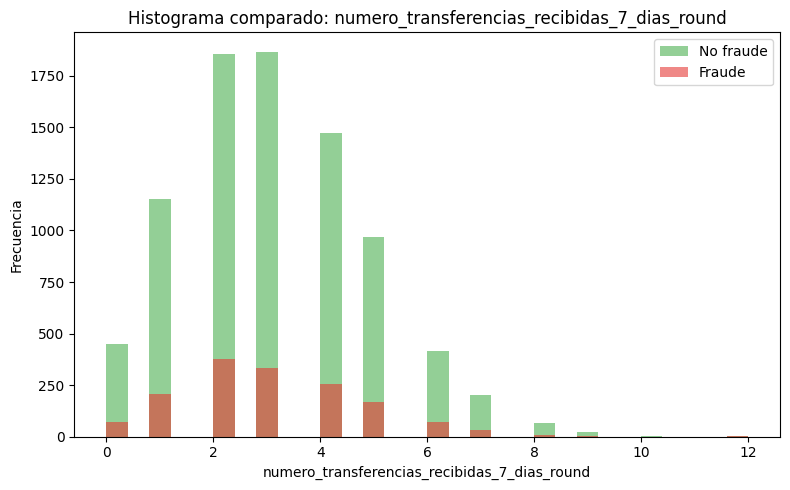

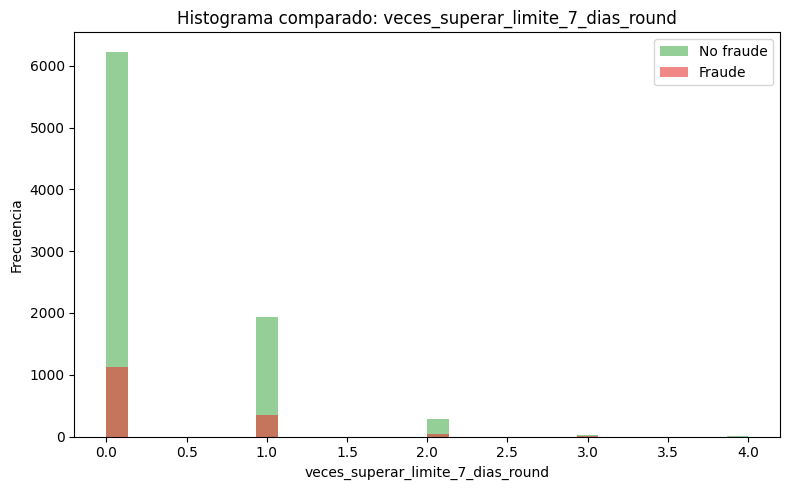

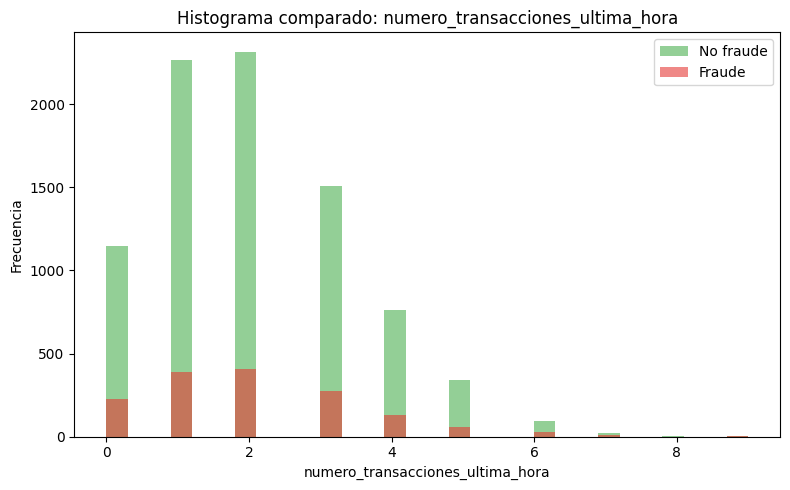

In [31]:
# Histogramas superpuestos para ver si la distribución difiere entre clases
df_plot = df.copy()

df_plot['media_transacciones_al_dia_round'] = df_plot['media_transacciones_al_dia'].round()
df_plot['numero_transferencias_enviadas_7_dias_round'] = df_plot['numero_transferencias_enviadas_7_dias'].round()
df_plot['numero_transferencias_recibidas_7_dias_round'] = df_plot['numero_transferencias_recibidas_7_dias'].round()
df_plot['veces_superar_limite_7_dias_round'] = df_plot['veces_superar_limite_7_dias'].round()

variables = [
    'edad_cliente',
    'media_transacciones_al_dia_round',
    'numero_transferencias_enviadas_7_dias_round',
    'numero_transferencias_recibidas_7_dias_round',
    'veces_superar_limite_7_dias_round',
    'numero_transacciones_ultima_hora'
]

for col in variables:
    plt.figure(figsize=(8, 5))
    
    plt.hist(
        df_plot[df_plot['IS_FRAUD'] == 0][col].dropna(),
        bins=30,
        alpha=0.6,
        label='No fraude',
        color='#4CAF50'
    )
    
    plt.hist(
        df_plot[df_plot['IS_FRAUD'] == 1][col].dropna(),
        bins=30,
        alpha=0.6,
        label='Fraude',
        color='#E53935'
    )
    
    plt.title(f'Histograma comparado: {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.tight_layout()
    plt.show()

> **Hallazgo 5.1 — Histogramas numéricos vs IS_FRAUD:**  
> La mayoría de variables numéricas muestran distribuciones muy similares entre clases, lo que confirma que ninguna variable individual es discriminante por sí sola. `importe_transaccion` muestra la diferencia más visible: las transacciones fraudulentas tienen una cola derecha más pesada (importes grandes sobrerrepresentados en fraude).

### 5.2 Proporción de fraude por valor discreto

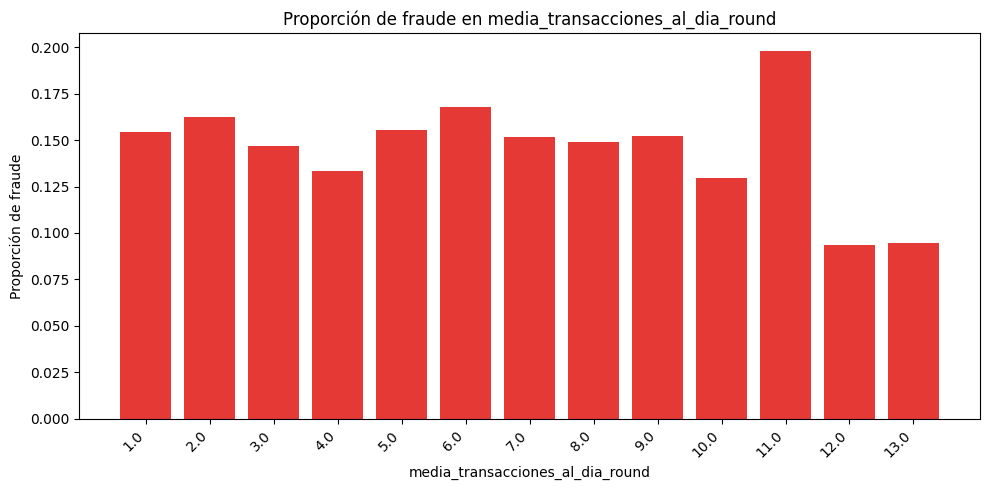

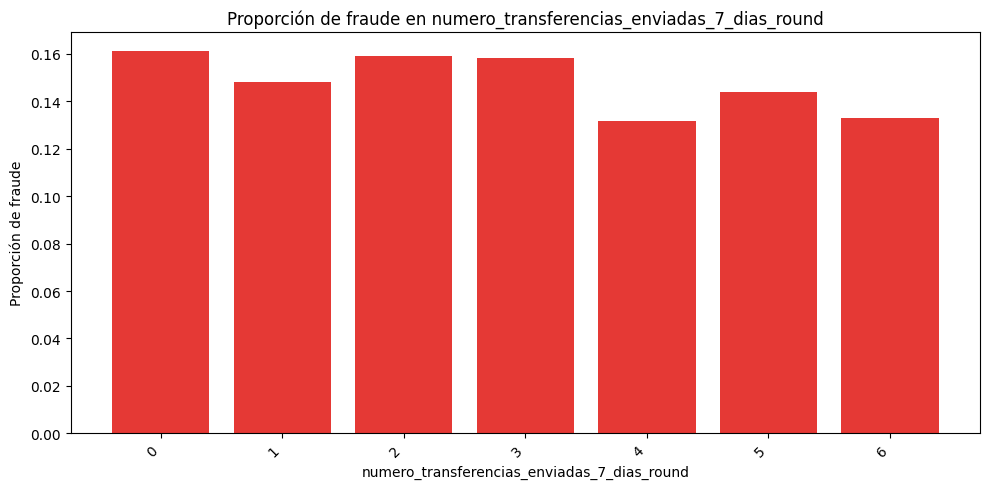

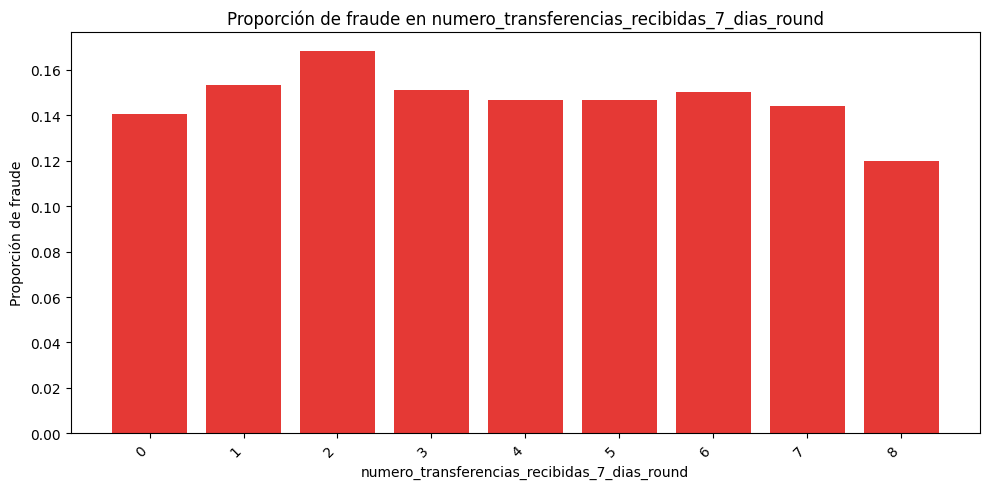

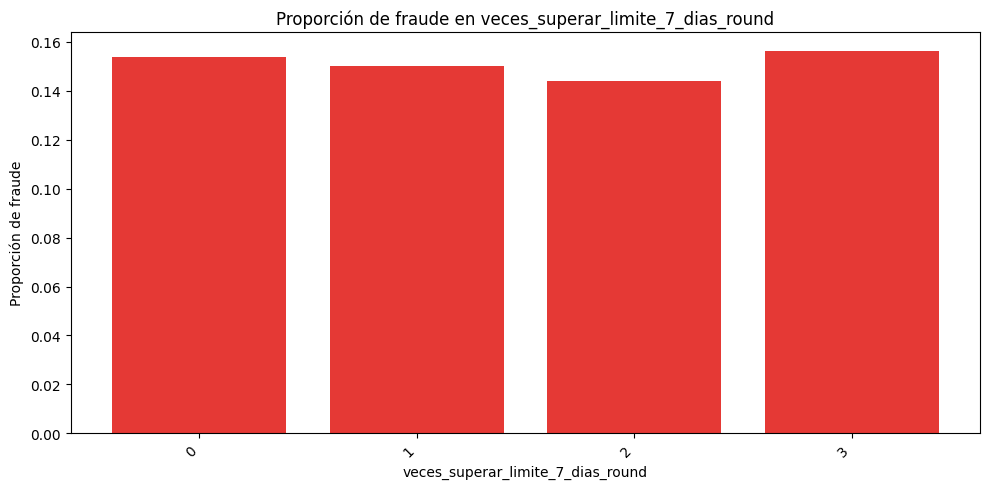

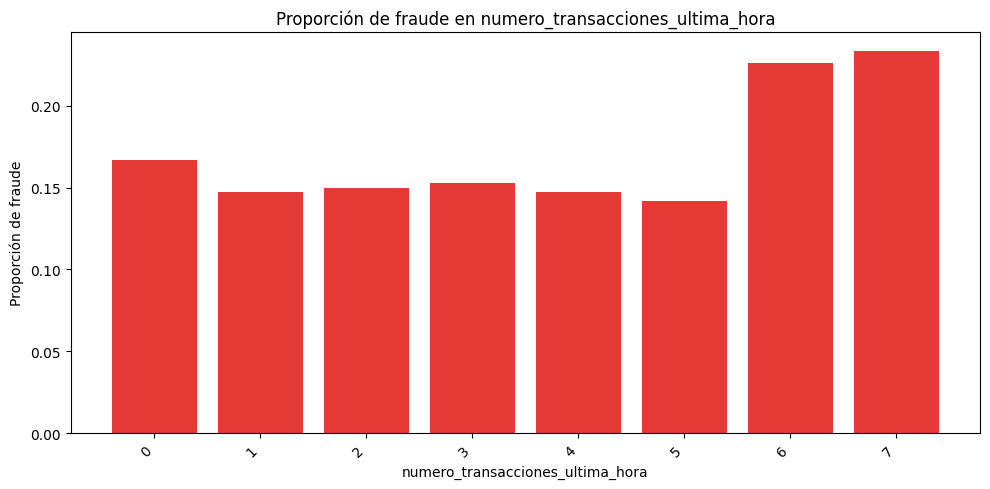

In [32]:
# Para variables discretas: fraud rate en cada valor (mínimo 30 obs. por grupo)
variables = [
    'media_transacciones_al_dia_round',
    'numero_transferencias_enviadas_7_dias_round',
    'numero_transferencias_recibidas_7_dias_round',
    'veces_superar_limite_7_dias_round',
    'numero_transacciones_ultima_hora'
]

min_obs = 30

for col in variables:
    resumen = (
        df_plot.groupby(col, observed=False)
        .agg(
            total=('IS_FRAUD', 'size'),
            fraude_rate=('IS_FRAUD', 'mean')
        )
        .reset_index()
    )

    resumen = resumen[resumen['total'] >= min_obs]
    resumen = resumen.sort_values(col)

    plt.figure(figsize=(10, 5))
    plt.bar(resumen[col].astype(str), resumen['fraude_rate'], color='#E53935')
    plt.title(f'Proporción de fraude en {col}')
    plt.xlabel(col)
    plt.ylabel('Proporción de fraude')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

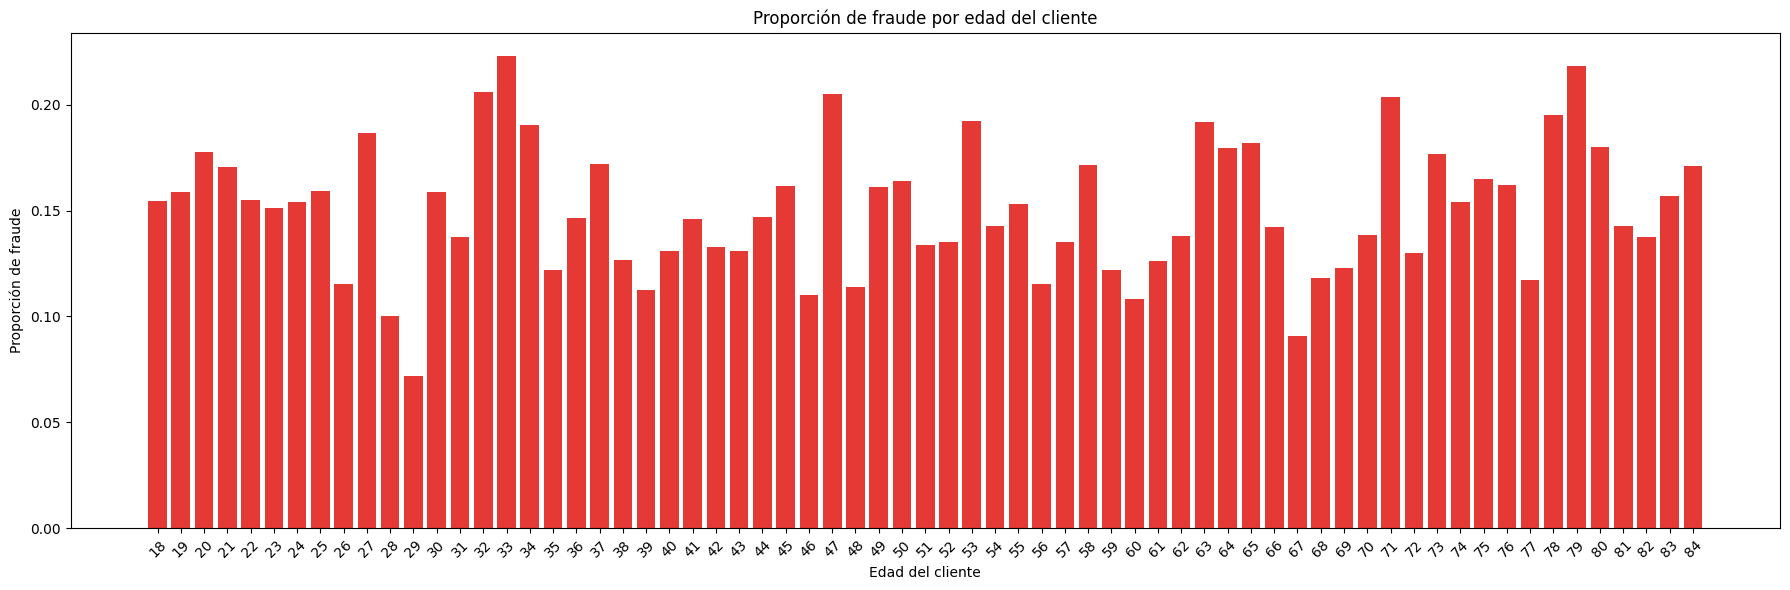

In [33]:
# Misma lógica aplicada a la edad del cliente
min_obs = 30

resumen_edad = (
    df.groupby('edad_cliente', observed=False)
    .agg(
        total=('IS_FRAUD', 'size'),
        fraude_rate=('IS_FRAUD', 'mean')
    )
    .reset_index()
)

resumen_edad = resumen_edad[resumen_edad['total'] >= min_obs]
resumen_edad = resumen_edad.sort_values('edad_cliente')

plt.figure(figsize=(18, 6))
plt.bar(resumen_edad['edad_cliente'].astype(str), resumen_edad['fraude_rate'], color='#E53935')
plt.title('Proporción de fraude por edad del cliente')
plt.xlabel('Edad del cliente')
plt.ylabel('Proporción de fraude')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Hallazgo 5.2 — Proporciones de fraude por valor discreto:**  
> Variables como `veces_superar_limite_7_dias` y `numero_transferencias_enviadas_7_dias` muestran fraud rate creciente con el valor — a mayor actividad inusual, más fraude. `edad_cliente` no presenta un patrón claro; el fraude afecta a todos los rangos de edad de forma bastante uniforme en este dataset sintético.

## 6. Correlaciones

### 6.1 Variables numéricas — Correlación de Pearson con `IS_FRAUD`

Las correlaciones lineales con la variable objetivo son en general débiles,
lo cual es habitual en fraude: no hay una sola variable que lo explique todo.

In [34]:
# Correlación de Pearson de cada variable numérica con IS_FRAUD
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
numeric_cols.remove('IS_FRAUD')

corr_target = df[numeric_cols + ['IS_FRAUD']].corr()['IS_FRAUD'].drop('IS_FRAUD')
corr_target = corr_target.sort_values(key=abs, ascending=False)

print(corr_target)

destino_alto_riesgo                       0.187777
dispositivo_reconocido                   -0.086941
importe_transaccion                       0.084366
numero_fraudes_ultimo_ano                 0.038864
importe_medio_mensual                     0.032668
is_night                                  0.013616
numero_pin_disponibles                    0.012932
numero_transferencias_recibidas_7_dias   -0.012812
tenure                                    0.012630
limite_importe_transacciones             -0.012196
mes                                      -0.011541
numero_transferencias_enviadas_7_dias    -0.010818
media_transacciones_al_dia               -0.010290
saldo_medio_30_dias                       0.009384
saldo_actual                              0.008013
tiempo_desde_ultima_min                   0.007846
tiempo_desde_ultima_horas                 0.007846
tiempo_desde_ultima_transaccion           0.007846
tiempo_desde_ultima_dias                  0.007846
is_weekend                     

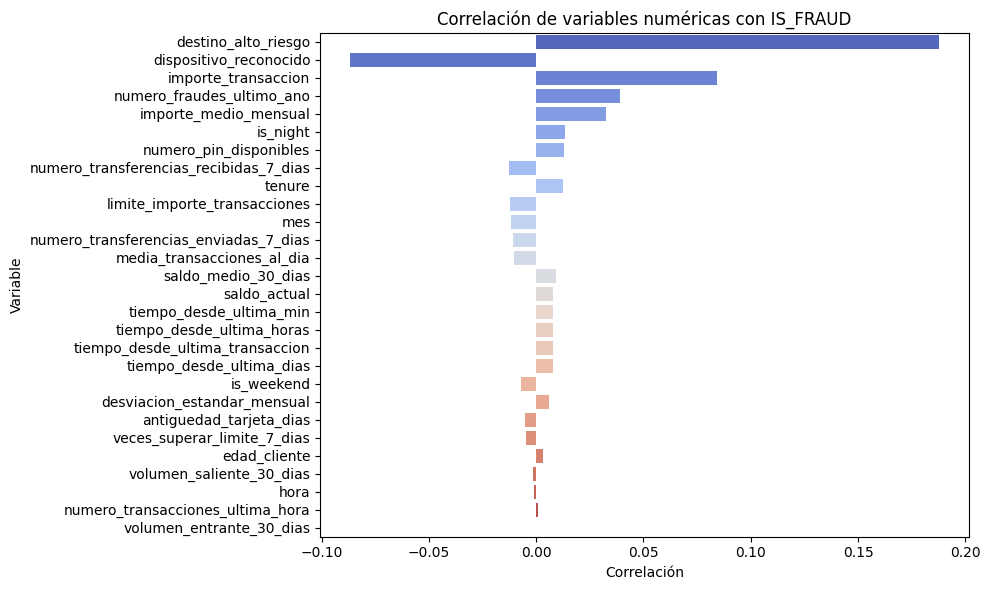

In [35]:
# Visualización de las correlaciones ordenadas por valor absoluto
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_target.values, y=corr_target.index, hue=corr_target.index, palette='coolwarm', legend=False)
plt.title('Correlación de variables numéricas con IS_FRAUD')
plt.xlabel('Correlación')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

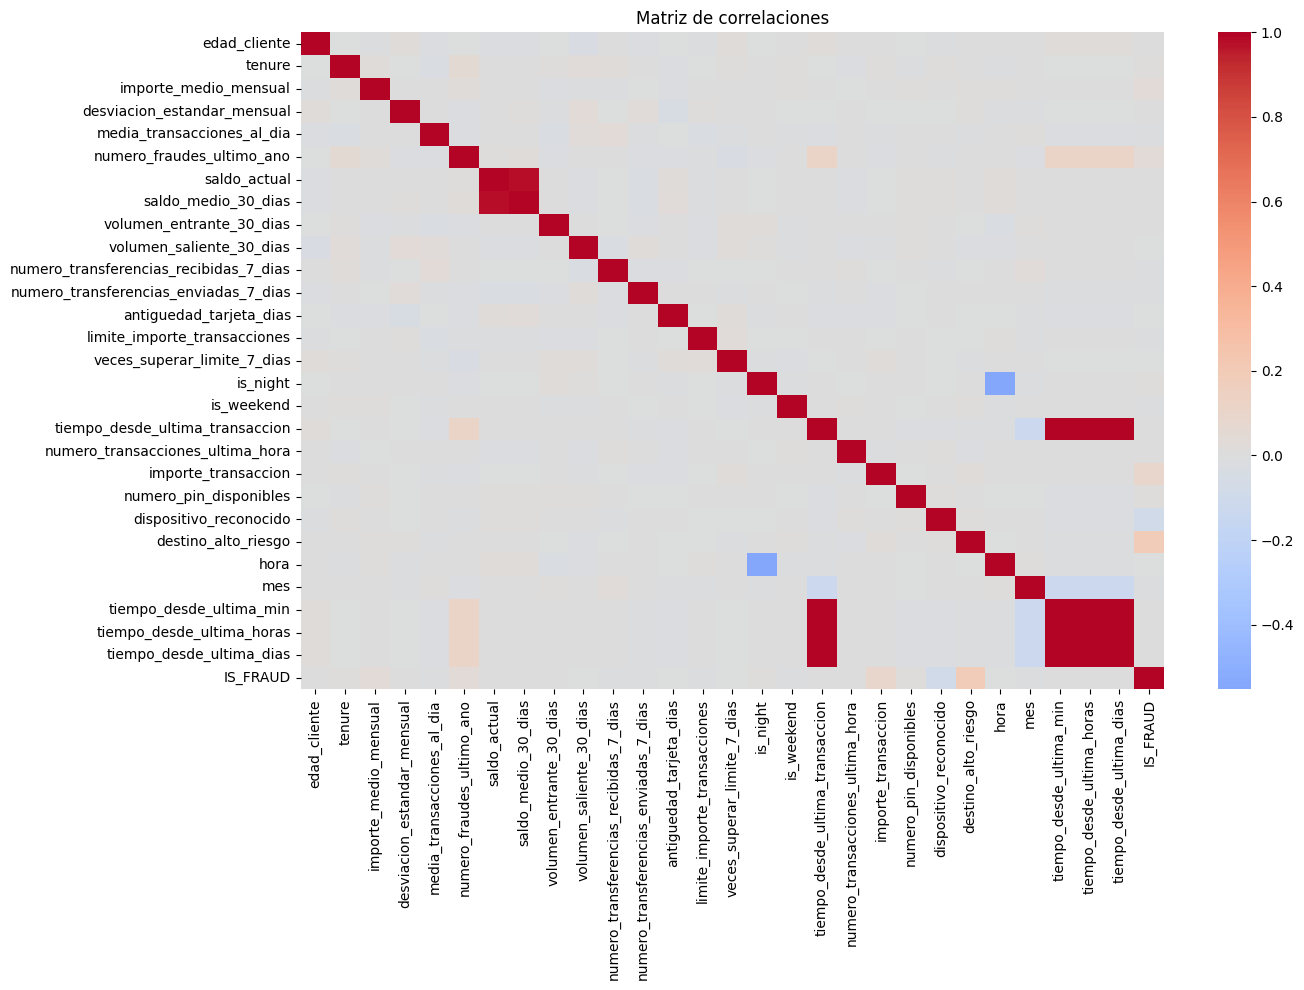

In [36]:
# Matriz de correlaciones entre todas las variables numéricas
plt.figure(figsize=(14, 10))
sns.heatmap(df[numeric_cols + ['IS_FRAUD']].corr(), cmap='coolwarm', center=0)
plt.title('Matriz de correlaciones')
plt.tight_layout()
plt.show()

In [37]:
corr = df[numeric_cols + ['IS_FRAUD']].corr()

mask = np.triu(np.ones(corr.shape), k=0).astype(bool)

corr_pairs = (
    corr.mask(mask)
    .stack()
    .reset_index()
)

corr_pairs.columns = ['var_1', 'var_2', 'corr']
corr_pairs['abs_corr'] = corr_pairs['corr'].abs()

corr_pairs = corr_pairs[corr_pairs['abs_corr'] >= 0.1]
corr_pairs = corr_pairs.sort_values('abs_corr', ascending=False)

display(corr_pairs)

,var_1,var_2,corr,abs_corr
800,tiempo_desde_ultima_dias,tiempo_desde_ultima_transaccion,1.000000,1.000000
742,tiempo_desde_ultima_min,tiempo_desde_ultima_transaccion,1.000000,1.000000
779,tiempo_desde_ultima_horas,tiempo_desde_ultima_min,1.000000,1.000000
808,tiempo_desde_ultima_dias,tiempo_desde_ultima_min,1.000000,1.000000
771,tiempo_desde_ultima_horas,tiempo_desde_ultima_transaccion,1.000000,1.000000
809,tiempo_desde_ultima_dias,tiempo_desde_ultima_horas,1.000000,1.000000
209,saldo_medio_30_dias,saldo_actual,0.981293,0.981293
682,hora,is_night,-0.552940,0.552940
834,IS_FRAUD,destino_alto_riesgo,0.187777,0.187777
749,tiempo_desde_ultima_min,mes,-0.124012,0.124012


> **Hallazgo 6.1 — Correlaciones de Pearson:**  
> Las correlaciones lineales con `IS_FRAUD` son débiles en general. Las tres variables con mayor señal individual son `destino_alto_riesgo` (+0.19), `dispositivo_reconocido` (−0.09) e `importe_transaccion` (+0.08). La baja correlación lineal **no implica baja utilidad predictiva** — los modelos no lineales (árboles, gradient boosting) pueden capturar relaciones que Pearson no detecta.

### 6.2 Variables categóricas — Cramér's V

Cramér's V mide la asociación entre variables categóricas e `IS_FRAUD`
(0 = sin relación, 1 = relación perfecta).
Se acompaña del p-value del test chi² para valorar significatividad estadística.

In [38]:
# Cramér's V + chi² para cada variable categórica (excluimos IDs y fechas crudas)
# Cramér's V + chi² para cada variable categórica relevante (excluimos IDs y fechas crudas)
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

# CategÃ³ricas Ãºtiles para anÃ¡lisis
categorical_cols = [
    col for col in df.select_dtypes(include=['object', 'category', 'string']).columns
    if col not in [
        'id_cliente',
        'id_cuenta',
        'id_tarjeta',
        'id_transaccion',
        'direccion_ip_origen',
        'identificador_dispositivo_fingerprint',
        'fecha_hora',
        'fecha_creacion_tarjeta'
    ]
]

def cramers_v(tabla):
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

resultados = []

for col in categorical_cols:
    tabla = pd.crosstab(df[col], df['IS_FRAUD'])

    if tabla.shape[0] > 1 and tabla.shape[1] > 1:
        chi2, p_value, _, _ = chi2_contingency(tabla)
        v = cramers_v(tabla)

        resultados.append({
            'variable': col,
            'n_categorias': df[col].nunique(),
            'cramers_v': v,
            'p_value': p_value
        })

relacion_categoricas = pd.DataFrame(resultados).sort_values('cramers_v', ascending=False)

relacion_categoricas['cramers_v'] = relacion_categoricas['cramers_v'].round(3)
relacion_categoricas['p_value'] = relacion_categoricas['p_value'].round(6)

display(relacion_categoricas)

,variable,n_categorias,cramers_v,p_value
3,cuenta_origen,3548,0.607,0.055614
11,cuenta_destino,500,0.290,0.000000
5,estado_tarjeta,5,0.226,0.000000
17,riesgo_label,2,0.187,0.000000
12,fecha,183,0.130,0.725512
15,importe_bin,5,0.095,0.000000
16,dispositivo_label,2,0.087,0.000000
4,estado_cuenta,4,0.075,0.000000
9,operacion_region,30,0.073,0.003216
6,tipo_transaccion,2,0.072,0.000000


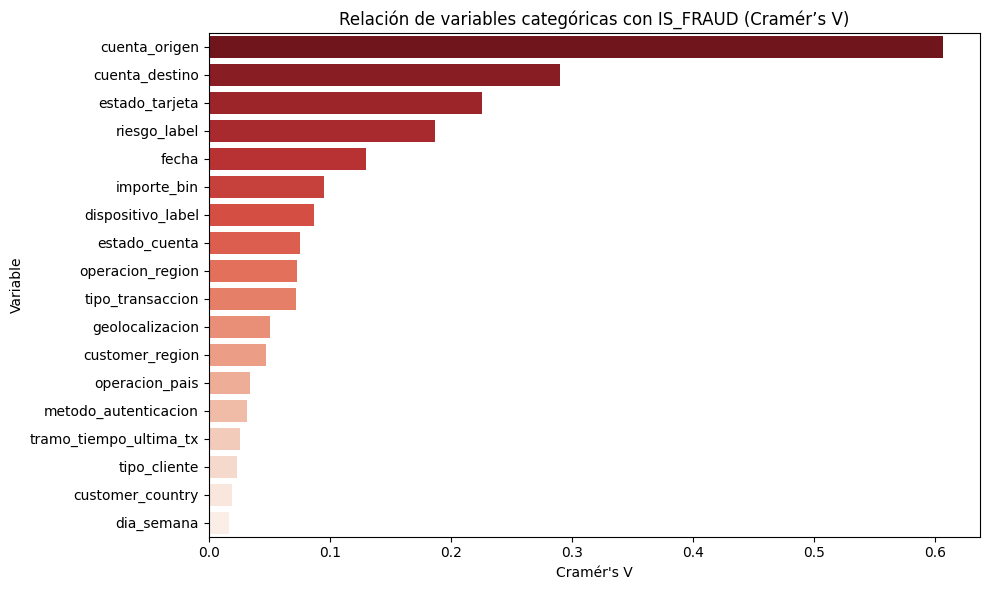

In [39]:
# Barplot de Cramér's V — ordenado de mayor a menor asociación
# Barplot de Cramér's V — ordenado de mayor a menor asociación
plt.figure(figsize=(10, 6))
sns.barplot(
    data=relacion_categoricas,
    x='cramers_v',
    y='variable',
    hue='variable',
    palette='Reds_r',
    legend=False
)
plt.title('Relación de variables categóricas con IS_FRAUD (Cramér’s V)')
plt.xlabel("Cramér's V")
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

> **Hallazgo 6.2 — Asociación con variables categóricas (Cramér's V):**  
> `cuenta_destino` (V=0.29) y `estado_tarjeta` (V=0.23) son las variables categóricas con mayor asociación estadística con el fraude. `destino_alto_riesgo` (V=0.19) y `dispositivo_reconocido` (V=0.09) confirman su relevancia. `cuenta_origen` presenta un V=0.61 anómalo con p-value no significativo → se investiga en la sección siguiente.

### 6.3 Investigación de `cuenta_origen`

`cuenta_origen` tiene un Cramér's V muy alto (0.61) pero p-value en el límite (0.056).
Investigamos si hay cuentas que concentran casi todo el fraude
y si eso explica el resultado estadístico.

In [40]:
# Investiggar cuenta origen
resumen_cuenta_origen = (
    df.groupby('cuenta_origen')['IS_FRAUD']
    .agg(
        total='size',
        fraudes='sum',
        fraud_rate='mean'
    )
    .reset_index()
    .sort_values(['fraud_rate', 'total'], ascending=[False, False])
)

display(resumen_cuenta_origen.head(20))

,cuenta_origen,total,fraudes,fraud_rate
849,ES321605236661,4,4,1.0
220,ES161188244078,3,3,1.0
2614,ES747381122470,3,3,1.0
3451,ES963587456259,3,3,1.0
3527,ES983498233145,3,3,1.0
47,ES111775970257,2,2,1.0
235,ES164952199221,2,2,1.0
262,ES174141917749,2,2,1.0
499,ES229787900279,2,2,1.0
546,ES243760622567,2,2,1.0


In [41]:
# Investigar cuenta origen
print("Cuentas con 100% fraude y al menos 2 observaciones:",
      ((resumen_cuenta_origen['fraud_rate'] == 1) & (resumen_cuenta_origen['total'] >= 2)).sum())

print("Cuentas con 100% fraude y al menos 3 observaciones:",
      ((resumen_cuenta_origen['fraud_rate'] == 1) & (resumen_cuenta_origen['total'] >= 3)).sum())

print("Cuentas con fraud_rate >= 0.8 y al menos 5 observaciones:",
      ((resumen_cuenta_origen['fraud_rate'] >= 0.8) & (resumen_cuenta_origen['total'] >= 5)).sum())

print("Cuentas con fraud_rate >= 0.5 y al menos 5 observaciones:",
      ((resumen_cuenta_origen['fraud_rate'] >= 0.5) & (resumen_cuenta_origen['total'] >= 5)).sum())

Cuentas con 100% fraude y al menos 2 observaciones: 24
Cuentas con 100% fraude y al menos 3 observaciones: 5
Cuentas con fraud_rate >= 0.8 y al menos 5 observaciones: 5
Cuentas con fraud_rate >= 0.5 y al menos 5 observaciones: 30


In [42]:
# Investigar cuenta origen
cuentas_extremas = resumen_cuenta_origen[
    (resumen_cuenta_origen['fraud_rate'] >= 0.8) &
    (resumen_cuenta_origen['total'] >= 5)
]

display(cuentas_extremas)

,cuenta_origen,total,fraudes,fraud_rate
422,ES211532313427,6,5,0.833333
2127,ES631836570211,5,4,0.800000
2232,ES658845924491,5,4,0.800000
2578,ES742181672834,5,4,0.800000
2914,ES825777943641,5,4,0.800000


In [43]:
# Investigar cuenta origen (ver fragmentacion de la variable)
distribucion_frecuencia_cuentas = (
    resumen_cuenta_origen['total']
    .value_counts()
    .sort_index()
    .reset_index()
)

distribucion_frecuencia_cuentas.columns = ['n_operaciones_por_cuenta', 'n_cuentas']

display(distribucion_frecuencia_cuentas.head(15))

,n_operaciones_por_cuenta,n_cuentas
0,1,886
1,2,874
2,3,743
3,4,511
4,5,276
5,6,153
6,7,63
7,8,27
8,9,12
9,10,3


In [44]:
# Investigar cuenta origen
print("Porcentaje de cuentas con 1 observación:",
      (resumen_cuenta_origen['total'] == 1).mean() * 100)

print("Porcentaje de cuentas con 2 o menos observaciones:",
      (resumen_cuenta_origen['total'] <= 2).mean() * 100)

print("Porcentaje de cuentas con 3 o menos observaciones:",
      (resumen_cuenta_origen['total'] <= 3).mean() * 100)

Porcentaje de cuentas con 1 observación: 24.971815107102593
Porcentaje de cuentas con 2 o menos observaciones: 49.6054114994363
Porcentaje de cuentas con 3 o menos observaciones: 70.54678692220969


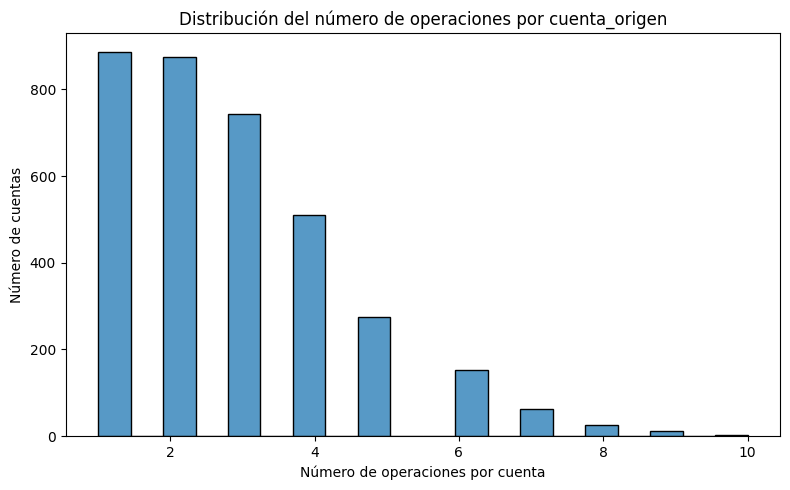

In [45]:
# Visualizacion
plt.figure(figsize=(8, 5))
sns.histplot(resumen_cuenta_origen['total'], bins=20, color='#1f77b4')
plt.title('Distribución del número de operaciones por cuenta_origen')
plt.xlabel('Número de operaciones por cuenta')
plt.ylabel('Número de cuentas')
plt.tight_layout()
plt.show()

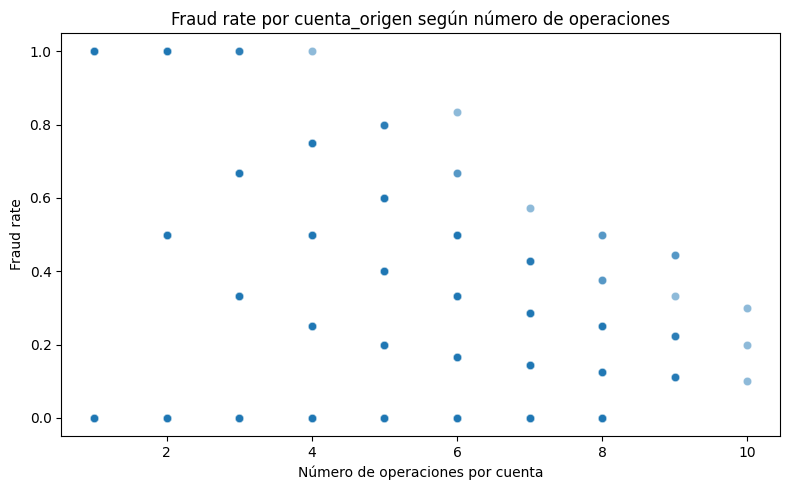

In [46]:
# Relacion volumen x fraud rate
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=resumen_cuenta_origen,
    x='total',
    y='fraud_rate',
    alpha=0.5
)
plt.title('Fraud rate por cuenta_origen según número de operaciones')
plt.xlabel('Número de operaciones por cuenta')
plt.ylabel('Fraud rate')
plt.tight_layout()
plt.show()

> **Hallazgo 6.3 — Investigación de `cuenta_origen`:**  
> El análisis confirma que hay **pocas cuentas de origen con fraud rate del 100%** pero con un número muy reducido de transacciones (1–2 observaciones). Esto es un artefacto del dataset sintético: cuentas "spammer" artificiales con cardinalidad muy alta que distorsionan Cramér's V. **Recomendación:** no usar `cuenta_origen` directa como feature; si se usa, aplicar target encoding con suavizado o un umbral mínimo de observaciones para evitar data leakage.

## 7. Análisis multivariante — Interacciones entre variables

Exploramos combinaciones de variables para detectar patrones que no son
visibles de forma univariante.

### 7.1 Interacción detallada: importe × dispositivo reconocido

In [47]:
# Creamos tramos de importe por quintiles
# Creamos tramos de importe por quintiles (si no existen ya del paso anterior)
df['importe_tramo'] = pd.qcut(
    df['importe_transaccion'],
    q=5,
    duplicates='drop'
)

In [48]:
# Tabla resumen: fraud rate por tramo de importe y tipo de dispositivo
# Tabla resumen: fraud rate por tramo de importe y tipo de dispositivo
tabla_resumen = (
    df.groupby(['importe_tramo', 'dispositivo_reconocido'])['IS_FRAUD']
    .agg(
        total='size',
        fraud_rate='mean'
    )
    .reset_index()
)

tabla_resumen

,importe_tramo,dispositivo_reconocido,total,fraud_rate
0,"(0.519, 42.036]",0,329,0.173252
1,"(0.519, 42.036]",1,1671,0.120287
2,"(42.036, 102.526]",0,314,0.226115
3,"(42.036, 102.526]",1,1686,0.119810
4,"(102.526, 216.258]",0,285,0.210526
5,"(102.526, 216.258]",1,1715,0.117784
6,"(216.258, 532.904]",0,291,0.226804
7,"(216.258, 532.904]",1,1709,0.133411
8,"(532.904, 27088.38]",0,289,0.304498
9,"(532.904, 27088.38]",1,1711,0.205143


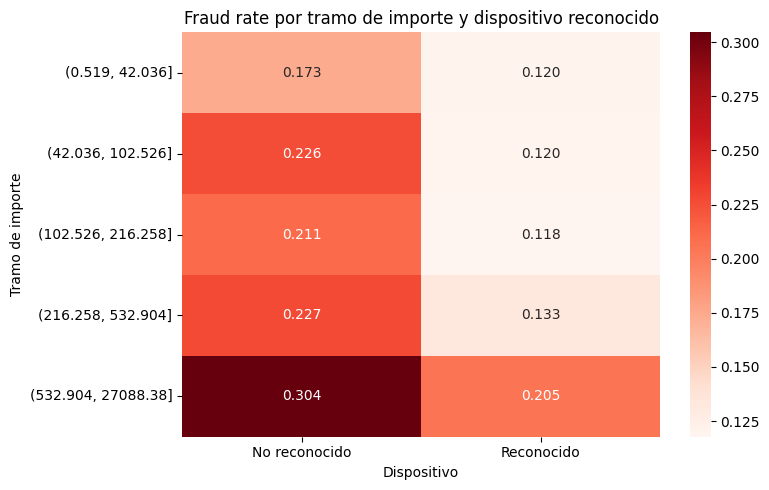

In [49]:
# Heatmap: fraud rate por tramo de importe × dispositivo reconocido
# Heatmap: fraud rate por tramo de importe × dispositivo reconocido
pivot_importe_dispositivo = df.pivot_table(
    values='IS_FRAUD',
    index='importe_tramo',
    columns='dispositivo_reconocido',
    aggfunc='mean'
)

pivot_importe_dispositivo = pivot_importe_dispositivo.rename(columns={
    0: 'No reconocido',
    1: 'Reconocido'
})

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_importe_dispositivo, cmap='Reds', annot=True, fmt='.3f')
plt.title('Fraud rate por tramo de importe y dispositivo reconocido')
plt.xlabel('Dispositivo')
plt.ylabel('Tramo de importe')
plt.tight_layout()
plt.show()

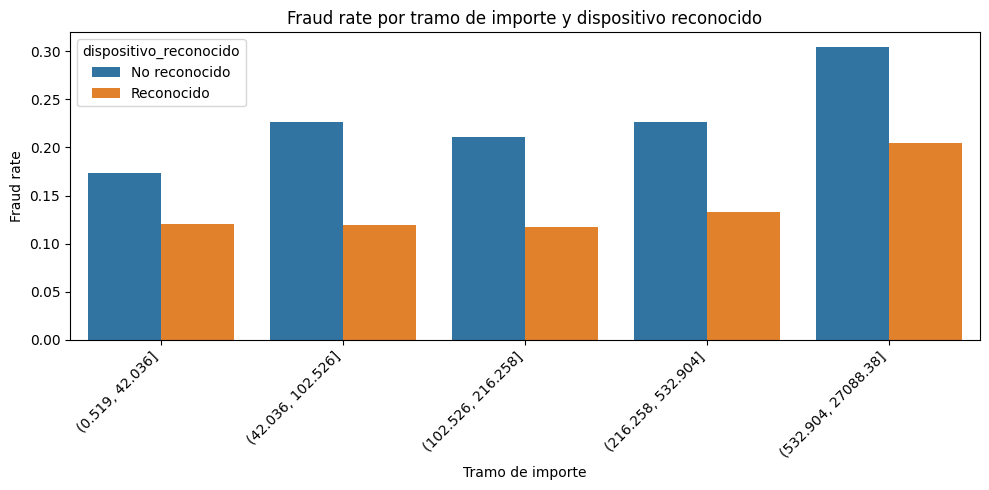

In [50]:
# Barplot alternativo para la misma combinación
# Barplot alternativo para la misma combinación
tabla_plot = tabla_resumen.copy()
tabla_plot['dispositivo_reconocido'] = tabla_plot['dispositivo_reconocido'].map({
    0: 'No reconocido',
    1: 'Reconocido'
})

plt.figure(figsize=(10, 5))
sns.barplot(
    data=tabla_plot,
    x='importe_tramo',
    y='fraud_rate',
    hue='dispositivo_reconocido'
)
plt.title('Fraud rate por tramo de importe y dispositivo reconocido')
plt.xlabel('Tramo de importe')
plt.ylabel('Fraud rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> **Hallazgo 7.1 — Interacción importe × dispositivo:**  
> La combinación de importe alto + dispositivo no reconocido alcanza fraud rates del ~30%, muy por encima de la media global (15.26%). Esta interacción es un candidato natural para un **feature de interacción explícito** en el modelo: `importe_alto AND dispositivo_no_reconocido`. El efecto es aditivo — cada factor por separado ya eleva el fraude, pero juntos lo amplifican.

### 7.2 Interacciones múltiples — Exploración sistemática

In [51]:
# Setup: etiquetas legibles y tramos para variables continuas
# Setup: etiquetas legibles y tramos para variables continuas usadas en los heatmaps
# Copia opcional para no ensuciar df original
df_inter = df.copy()

# Tramos necesarios
df_inter['importe_tramo'] = pd.qcut(
    df_inter['importe_transaccion'],
    q=5,
    duplicates='drop'
)

df_inter['tiempo_desde_ultima_tramo'] = pd.qcut(
    df_inter['tiempo_desde_ultima_transaccion'],
    q=5,
    duplicates='drop'
)

# Etiquetas para binarias
df_inter['is_night_label'] = df_inter['is_night'].map({
    0: 'No noche',
    1: 'Noche'
})

df_inter['dispositivo_label'] = df_inter['dispositivo_reconocido'].map({
    0: 'No reconocido',
    1: 'Reconocido'
})

df_inter['riesgo_label'] = df_inter['destino_alto_riesgo'].map({
    0: 'No alto riesgo',
    1: 'Alto riesgo'
})

In [52]:
# Función auxiliar: tabla de resumen + heatmap para cualquier par de variables
# Función auxiliar: genera tabla de resumen + heatmap para cualquier par de variables
def resumen_y_heatmap(df, fila, columna, titulo, figsize=(8, 5)):
    tabla_resumen = (
        df.groupby([fila, columna])['IS_FRAUD']
        .agg(total='size', fraud_rate='mean')
        .reset_index()
    )

    display(tabla_resumen)

    pivot = df.pivot_table(
        values='IS_FRAUD',
        index=fila,
        columns=columna,
        aggfunc='mean'
    )

    plt.figure(figsize=figsize)
    sns.heatmap(pivot, cmap='Reds', annot=True, fmt='.3f')
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

,numero_transacciones_ultima_hora,is_night_label,total,fraud_rate
0,0,No noche,971,0.159629
1,0,Noche,404,0.183168
2,1,No noche,1850,0.142162
3,1,Noche,809,0.158220
4,2,No noche,1896,0.146097
5,2,Noche,831,0.158845
6,3,No noche,1273,0.157109
7,3,Noche,507,0.142012
8,4,No noche,626,0.148562
9,4,Noche,271,0.143911


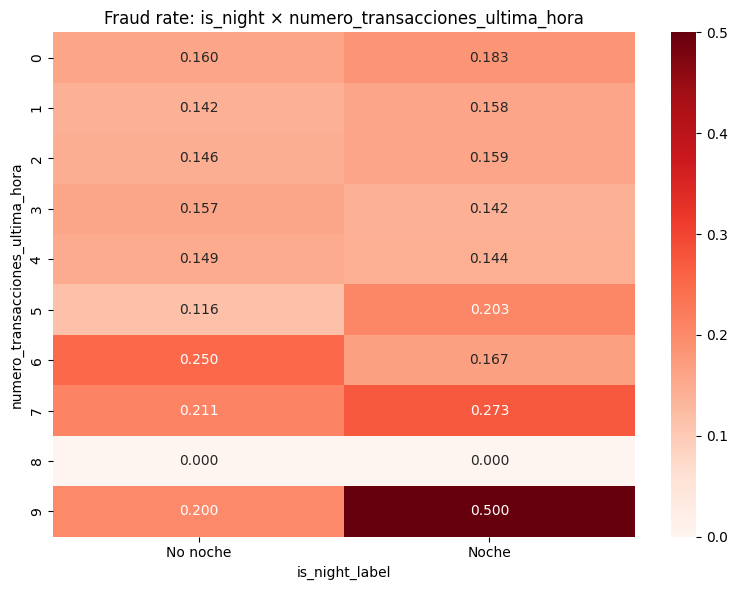

,importe_tramo,riesgo_label,total,fraud_rate
0,"(0.519, 42.036]",Alto riesgo,216,0.245370
1,"(0.519, 42.036]",No alto riesgo,1784,0.114910
2,"(42.036, 102.526]",Alto riesgo,238,0.306723
3,"(42.036, 102.526]",No alto riesgo,1762,0.113507
4,"(102.526, 216.258]",Alto riesgo,245,0.359184
5,"(102.526, 216.258]",No alto riesgo,1755,0.099145
6,"(216.258, 532.904]",Alto riesgo,238,0.336134
7,"(216.258, 532.904]",No alto riesgo,1762,0.121453
8,"(532.904, 27088.38]",Alto riesgo,252,0.420635
9,"(532.904, 27088.38]",No alto riesgo,1748,0.190503


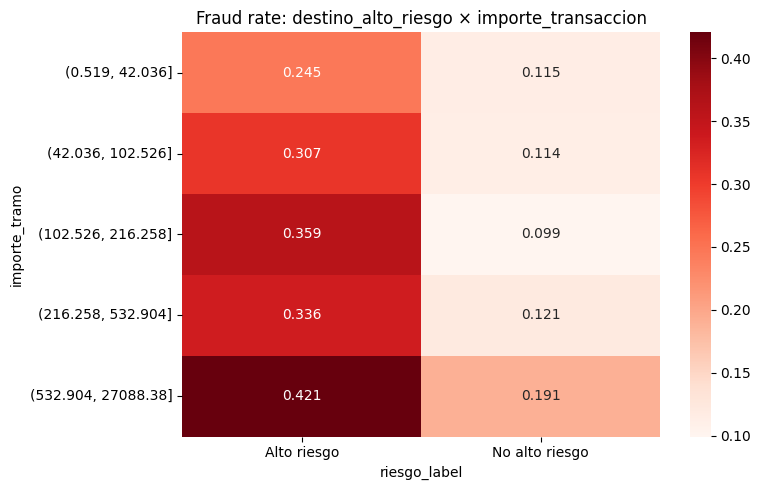

,customer_country,operacion_pais,total,fraud_rate
0,BR,BR,472,0.158898
1,BR,DE,5,0.200000
2,BR,ES,6,0.166667
3,BR,FR,8,0.500000
4,BR,GB,9,0.000000
...,...,...,...,...
59,US,FR,8,0.625000
60,US,GB,4,0.250000
61,US,IT,6,0.333333
62,US,PT,1,0.000000


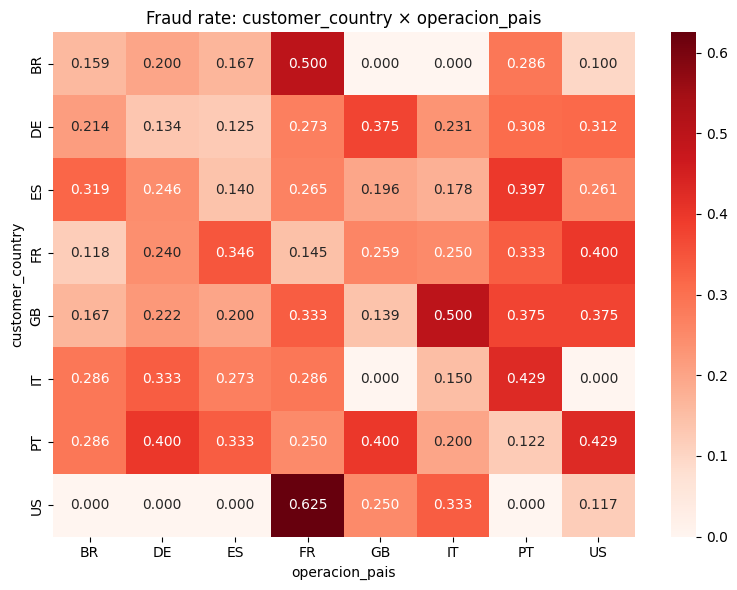

,metodo_autenticacion,dispositivo_label,total,fraud_rate
0,3DS,No reconocido,472,0.201271
1,3DS,Reconocido,2541,0.130264
2,PIN,No reconocido,581,0.234079
3,PIN,Reconocido,3428,0.136523
4,contactless,No reconocido,66,0.166667
5,contactless,Reconocido,469,0.172708
6,firma,No reconocido,231,0.264069
7,firma,Reconocido,1226,0.158238
8,huella,No reconocido,158,0.246835
9,huella,Reconocido,828,0.132850


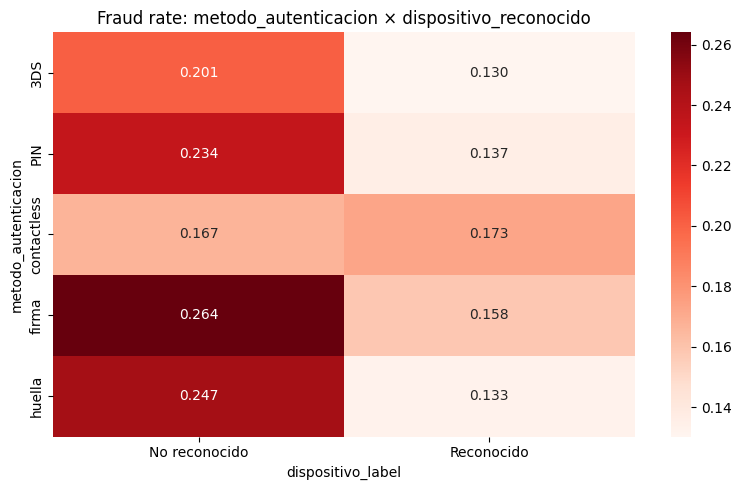

,numero_fraudes_ultimo_ano,riesgo_label,total,fraud_rate
0,0,Alto riesgo,797,0.329987
1,0,No alto riesgo,5994,0.118952
2,1,Alto riesgo,262,0.339695
3,1,No alto riesgo,1978,0.137513
4,2,Alto riesgo,97,0.402062
5,2,No alto riesgo,588,0.159864
6,3,Alto riesgo,23,0.304348
7,3,No alto riesgo,178,0.224719
8,4,Alto riesgo,8,0.250000
9,4,No alto riesgo,64,0.093750


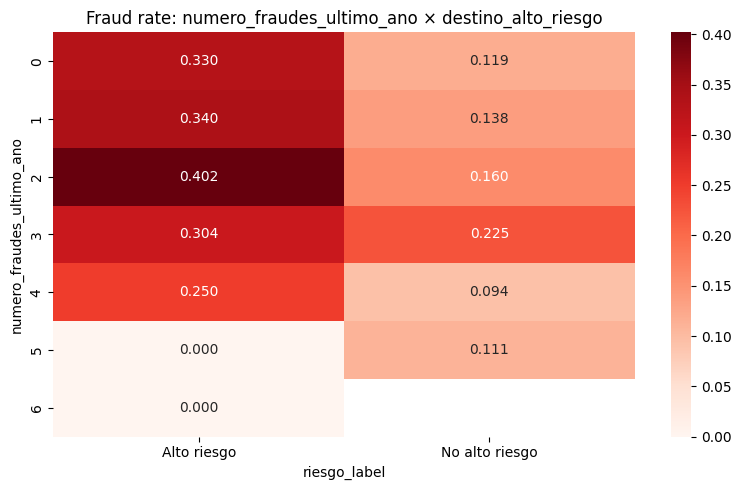

,estado_tarjeta,importe_tramo,total,fraud_rate
0,activa,"(0.519, 42.036]",1620,0.107407
1,activa,"(42.036, 102.526]",1577,0.102727
2,activa,"(102.526, 216.258]",1591,0.101194
3,activa,"(216.258, 532.904]",1596,0.119048
4,activa,"(532.904, 27088.38]",1600,0.195000
5,bloqueada,"(0.519, 42.036]",93,0.365591
6,bloqueada,"(42.036, 102.526]",88,0.386364
7,bloqueada,"(102.526, 216.258]",86,0.302326
8,bloqueada,"(216.258, 532.904]",87,0.344828
9,bloqueada,"(532.904, 27088.38]",94,0.382979


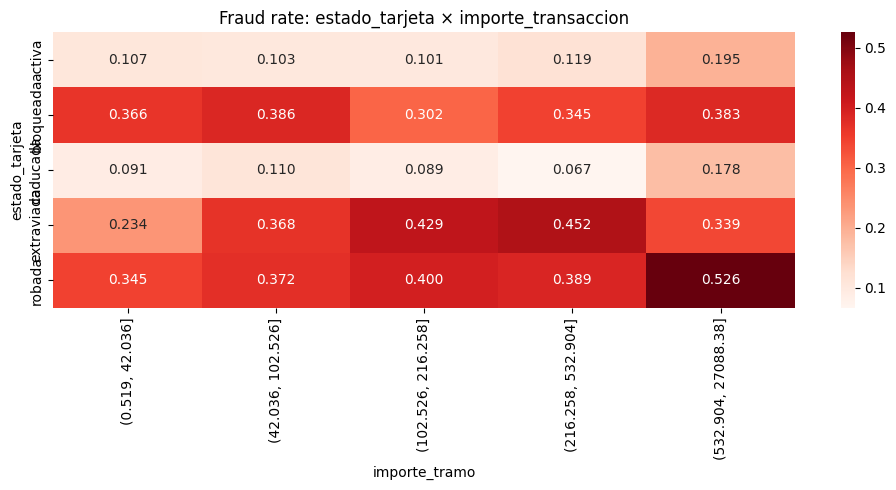

,tiempo_desde_ultima_tramo,numero_transacciones_ultima_hora,total,fraud_rate
0,"(-0.001, 27484.6]",0,527,0.172676
1,"(-0.001, 27484.6]",1,1089,0.155188
2,"(-0.001, 27484.6]",2,1107,0.147245
3,"(-0.001, 27484.6]",3,727,0.137552
4,"(-0.001, 27484.6]",4,346,0.127168
5,"(-0.001, 27484.6]",5,141,0.120567
6,"(-0.001, 27484.6]",6,44,0.204545
7,"(-0.001, 27484.6]",7,13,0.230769
8,"(-0.001, 27484.6]",8,3,0.000000
9,"(-0.001, 27484.6]",9,3,0.333333


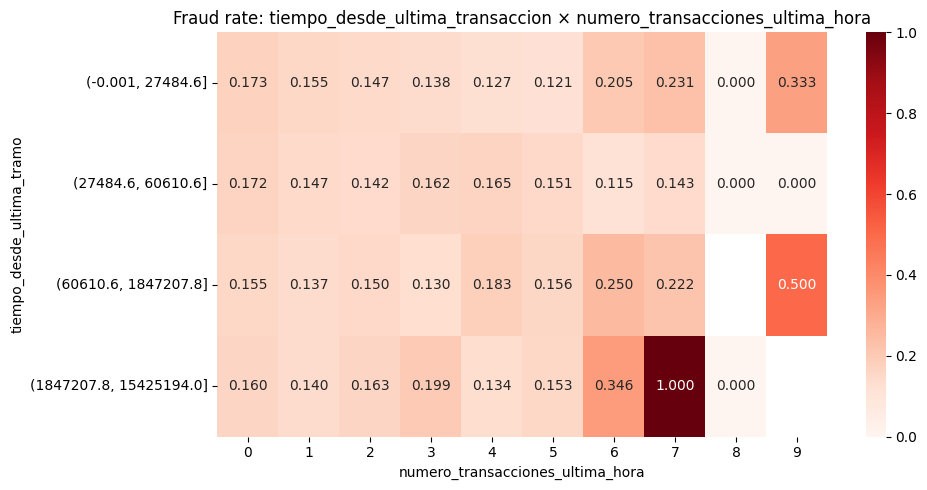

,is_night_label,riesgo_label,total,fraud_rate
0,No noche,Alto riesgo,821,0.314251
1,No noche,No alto riesgo,6187,0.127525
2,Noche,Alto riesgo,368,0.385870
3,Noche,No alto riesgo,2624,0.128430


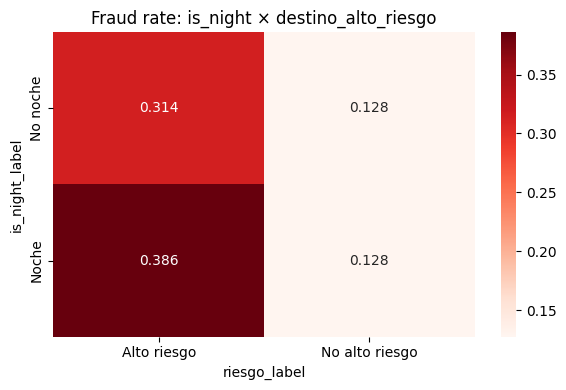

,tipo_transaccion,importe_tramo,total,fraud_rate
0,tarjeta,"(0.519, 42.036]",1421,0.108374
1,tarjeta,"(42.036, 102.526]",1411,0.115521
2,tarjeta,"(102.526, 216.258]",1408,0.114347
3,tarjeta,"(216.258, 532.904]",1415,0.142049
4,tarjeta,"(532.904, 27088.38]",1401,0.199143
5,transferencia,"(0.519, 42.036]",579,0.179620
6,transferencia,"(42.036, 102.526]",589,0.186757
7,transferencia,"(102.526, 216.258]",592,0.170608
8,transferencia,"(216.258, 532.904]",585,0.158974
9,transferencia,"(532.904, 27088.38]",599,0.267112


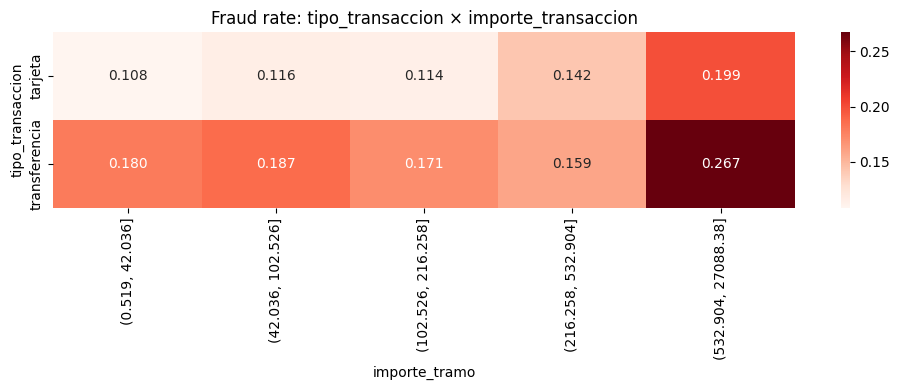

In [53]:
# Exploración de 9 combinaciones:
# 1. is_night × numero_transacciones_ultima_hora
# 2. destino_alto_riesgo × importe_transaccion
# 3. customer_country × operacion_pais
# 4. metodo_autenticacion × dispositivo_reconocido
# 5. numero_fraudes_ultimo_ano × destino_alto_riesgo
# 6. estado_tarjeta × importe_transaccion
# 7. tiempo_desde_ultima_transaccion × numero_transacciones_ultima_hora
# 8. is_night × destino_alto_riesgo
# 9. tipo_transaccion × importe_transaccion
# Exploración de 9 combinaciones de interacción:
# 1. is_night × numero_transacciones_ultima_hora
# 2. destino_alto_riesgo × importe_transaccion
# 3. customer_country × operacion_pais
# 4. metodo_autenticacion × dispositivo_reconocido
# 5. numero_fraudes_ultimo_ano × destino_alto_riesgo
# 6. estado_tarjeta × importe_transaccion
# 7. tiempo_desde_ultima_transaccion × numero_transacciones_ultima_hora
# 8. is_night × destino_alto_riesgo
# 9. tipo_transaccion × importe_transaccion
# 1. is_night × numero_transacciones_ultima_hora
resumen_y_heatmap(
    df_inter,
    'numero_transacciones_ultima_hora',
    'is_night_label',
    'Fraud rate: is_night × numero_transacciones_ultima_hora',
    figsize=(8, 6)
)

# 2. destino_alto_riesgo × importe_transaccion
resumen_y_heatmap(
    df_inter,
    'importe_tramo',
    'riesgo_label',
    'Fraud rate: destino_alto_riesgo × importe_transaccion',
    figsize=(8, 5)
)

# 3. customer_country × operacion_pais
resumen_y_heatmap(
    df_inter,
    'customer_country',
    'operacion_pais',
    'Fraud rate: customer_country × operacion_pais',
    figsize=(8, 6)
)

# 4. metodo_autenticacion × dispositivo_reconocido
resumen_y_heatmap(
    df_inter,
    'metodo_autenticacion',
    'dispositivo_label',
    'Fraud rate: metodo_autenticacion × dispositivo_reconocido',
    figsize=(8, 5)
)

# 5. numero_fraudes_ultimo_ano × destino_alto_riesgo
resumen_y_heatmap(
    df_inter,
    'numero_fraudes_ultimo_ano',
    'riesgo_label',
    'Fraud rate: numero_fraudes_ultimo_ano × destino_alto_riesgo',
    figsize=(8, 5)
)

# 6. estado_tarjeta × importe_transaccion
resumen_y_heatmap(
    df_inter,
    'estado_tarjeta',
    'importe_tramo',
    'Fraud rate: estado_tarjeta × importe_transaccion',
    figsize=(10, 5)
)

# 7. tiempo_desde_ultima_transaccion × numero_transacciones_ultima_hora
resumen_y_heatmap(
    df_inter,
    'tiempo_desde_ultima_tramo',
    'numero_transacciones_ultima_hora',
    'Fraud rate: tiempo_desde_ultima_transaccion × numero_transacciones_ultima_hora',
    figsize=(10, 5)
)

# 8. is_night × destino_alto_riesgo
resumen_y_heatmap(
    df_inter,
    'is_night_label',
    'riesgo_label',
    'Fraud rate: is_night × destino_alto_riesgo',
    figsize=(6, 4)
)

# 9. tipo_transaccion × importe_transaccion
resumen_y_heatmap(
    df_inter,
    'tipo_transaccion',
    'importe_tramo',
    'Fraud rate: tipo_transaccion × importe_transaccion',
    figsize=(10, 4)
)

> **Hallazgo 7.2 — Interacciones múltiples:**  
> Los cruces más informativos son: (1) `destino_alto_riesgo × importe_alto` (~40% fraud rate), (2) `estado_tarjeta × importe` (tarjetas bloqueadas con importe alto = máximo riesgo), y (3) `is_night × destino_alto_riesgo` (el destino de riesgo domina independientemente de la hora). El cruce `tiempo_desde_ultima_transaccion × numero_transacciones_ultima_hora` sugiere que las ráfagas rápidas de transacciones (muchas en poco tiempo) son una señal de fraude. Estas interacciones orientan el feature engineering del siguiente bloque.

## 8. Revisión de variables adicionales

Análisis de las variables que no habían sido examinadas individualmente: variables temporales, tipo de transacción, método de autenticación, comportamiento reciente, saldos y límites.

### 8.1 Estado de tarjeta y cuenta — riesgo de leakage

,estado_tarjeta,total,fraud_rate
4,robada,392,0.408163
3,extraviada,316,0.363924
1,bloqueada,448,0.357143
0,activa,7984,0.125125
2,caducada,860,0.106977


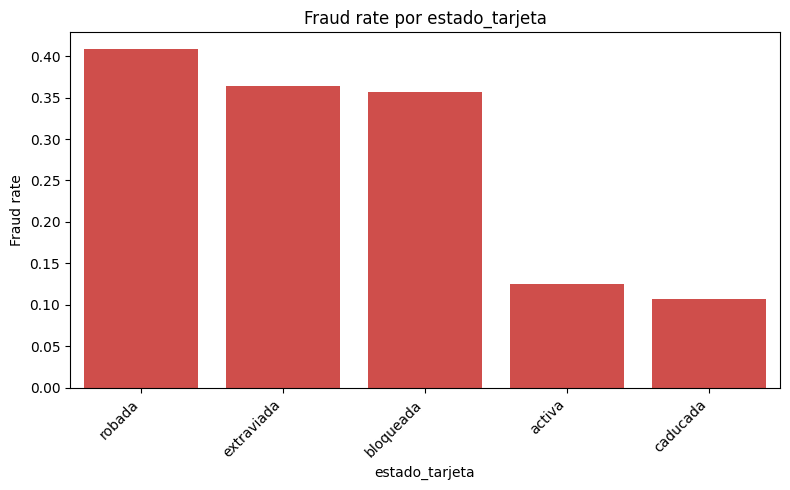

,estado_cuenta,total,fraud_rate
1,bloqueada,466,0.270386
0,activa,8480,0.149175
3,suspendida,556,0.138489
2,cerrada,498,0.116466


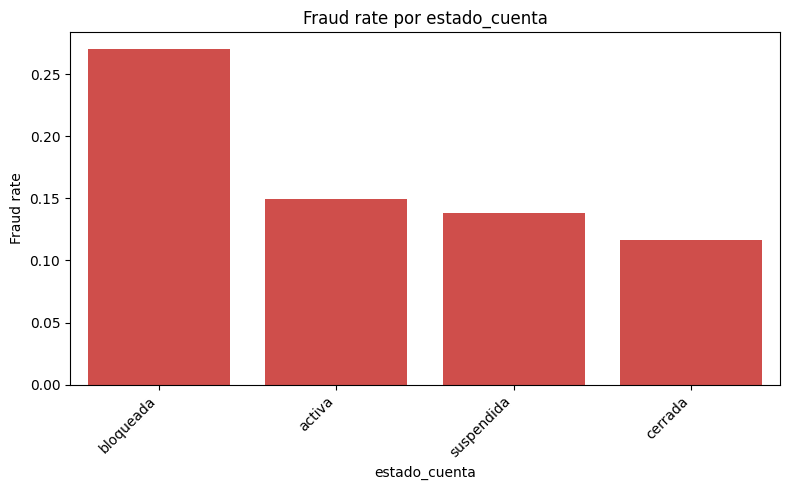

In [54]:
# Estado tarjeta - cuenta
for col in ['estado_tarjeta', 'estado_cuenta']:
    resumen = (
        df.groupby(col)['IS_FRAUD']
        .agg(total='size', fraud_rate='mean')
        .reset_index()
        .sort_values('fraud_rate', ascending=False)
    )

    display(resumen)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=resumen, x=col, y='fraud_rate', color='#E53935')
    plt.title(f'Fraud rate por {col}')
    plt.xlabel(col)
    plt.ylabel('Fraud rate')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

> **Hallazgo 8.1 — Leakage en `estado_tarjeta` y `estado_cuenta`:**  
> `estado_tarjeta` muestra diferencias muy marcadas: robada (40.8%), extraviada (36.4%), bloqueada (35.7%) vs activa (12.5%). `estado_cuenta` bloqueada aparece al 27%.  
> El problema es causal: en un dataset sintético no podemos garantizar que estos estados reflejen la situación *antes* de la transacción y no *después* de detectar el fraude. Además, `caducada` tiene fraud rate menor que la base (10.7%), lo que es incoherente con la lógica de negocio.  
> **Decisión: ambas variables fuera del train en la primera ronda.**

### 8.2 Variables temporales — `is_night` e `is_weekend`

,is_night,total,fraud_rate
0,0,7008,0.149401
1,1,2992,0.160094


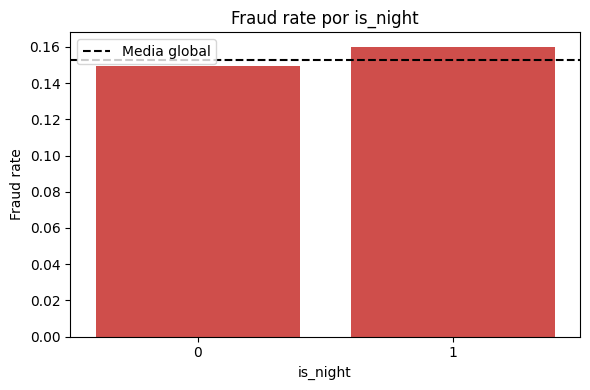

,is_weekend,total,fraud_rate
0,0,7157,0.154255
1,1,2843,0.148435


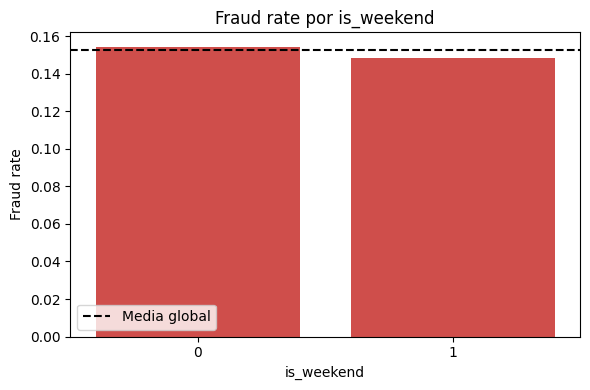

In [55]:
# is night - is weekend
base_rate = df['IS_FRAUD'].mean()

for col in ['is_night', 'is_weekend']:
    resumen = (
        df.groupby(col)['IS_FRAUD']
        .agg(total='size', fraud_rate='mean')
        .reset_index()
    )

    display(resumen)

    plt.figure(figsize=(6, 4))
    sns.barplot(data=resumen, x=col, y='fraud_rate', color='#E53935')
    plt.axhline(base_rate, color='black', linestyle='--', label='Media global')
    plt.title(f'Fraud rate por {col}')
    plt.xlabel(col)
    plt.ylabel('Fraud rate')
    plt.legend()
    plt.tight_layout()
    plt.show()

> **Hallazgo 8.2 — Variables temporales sin señal:**  
> `is_night`: 14.9% (día) vs 16.0% (noche). `is_weekend`: 15.4% vs 14.8%. Las diferencias son mínimas y prácticamente indistinguibles de la tasa base (15.3%).  
> **Decisión: ambas fuera del feature set — no aportan información discriminativa.**

### 8.3 Tipo de transacción

In [56]:
# tipo de transaccion explicito
resumen_tipo = (
    df.groupby('tipo_transaccion')['IS_FRAUD']
    .agg(total='size', fraud_rate='mean')
    .reset_index()
    .sort_values('fraud_rate', ascending=False)
)

display(resumen_tipo)

,tipo_transaccion,total,fraud_rate
1,transferencia,2944,0.192935
0,tarjeta,7056,0.135771


> **Hallazgo 8.3 — `tipo_transaccion` con señal clara:**  
> Transferencia: 19.3% de fraud rate vs tarjeta: 13.6%. Una diferencia de casi 6 puntos sobre la base, con buen volumen en ambas categorías (2.944 y 7.056 registros respectivamente).  
> **Decisión: incluir en el feature set.**

### 8.4 Método de autenticación

,metodo_autenticacion,total,fraud_rate
3,firma,1457,0.175017
2,contactless,535,0.171963
4,huella,986,0.151116
1,PIN,4009,0.150661
0,3DS,3013,0.141387


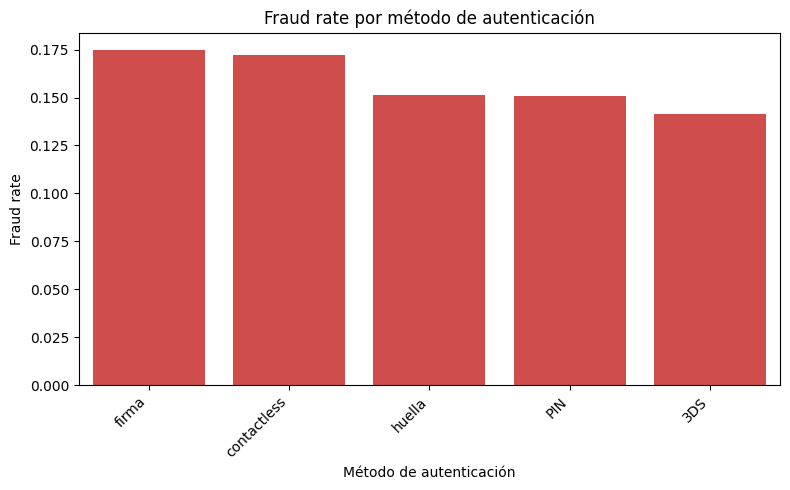

In [57]:
# Metodo de autenticacion explicito
resumen_auth = (
    df.groupby('metodo_autenticacion')['IS_FRAUD']
    .agg(total='size', fraud_rate='mean')
    .reset_index()
    .sort_values('fraud_rate', ascending=False)
)

display(resumen_auth)

plt.figure(figsize=(8, 5))
sns.barplot(data=resumen_auth, x='metodo_autenticacion', y='fraud_rate', color='#E53935')
plt.title('Fraud rate por método de autenticación')
plt.xlabel('Método de autenticación')
plt.ylabel('Fraud rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> **Hallazgo 8.4 — `metodo_autenticacion` con señal débil pero coherente:**  
> Firma (17.5%) y contactless (17.2%) ligeramente por encima de la base; 3DS (14.1%) por debajo, lo que tiene sentido (es el método más seguro). La separación es pequeña pero la dirección es lógica.  
> **Decisión: candidata opcional — puede incluirse, no es prioritaria.**

### 8.5 Comportamiento reciente — transacciones en la última hora

In [58]:
# Nº transacciones ultima hora explicito
resumen_num_tx = (
    df.groupby('numero_transacciones_ultima_hora')['IS_FRAUD']
    .agg(total='size', fraud_rate='mean')
    .reset_index()
    .sort_values('numero_transacciones_ultima_hora')
)

display(resumen_num_tx)

,numero_transacciones_ultima_hora,total,fraud_rate
0,0,1375,0.166545
1,1,2659,0.147048
2,2,2727,0.149982
3,3,1780,0.152809
4,4,897,0.147157
5,5,395,0.141772
6,6,124,0.225806
7,7,30,0.233333
8,8,6,0.000000
9,9,7,0.285714


> **Hallazgo 8.5 — `numero_transacciones_ultima_hora` prácticamente muerta:**  
> Correlación con IS_FRAUD de 0.0007. El fraud rate es plano (~15%) para todos los valores excepto 6+ (22.2%), pero ese tramo solo tiene 167 registros. No hay señal real aprovechable.  
> **Decisión: fuera del feature set.**

### 8.6 Multicolinealidad: `saldo_actual` vs `saldo_medio_30_dias`

,saldo_actual,saldo_medio_30_dias,IS_FRAUD
saldo_actual,1.000000,0.981293,0.008013
saldo_medio_30_dias,0.981293,1.000000,0.009384
IS_FRAUD,0.008013,0.009384,1.000000


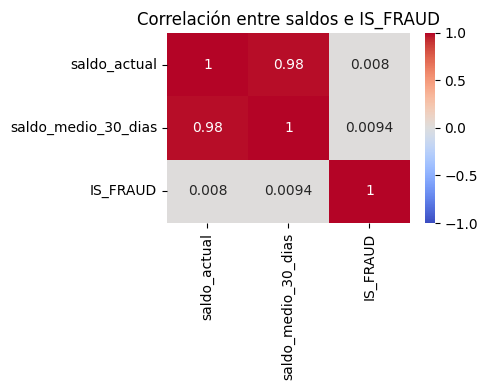

In [59]:
# Corr Para saldo_actual vs saldo_medio_30_dias
corr_saldos = df[['saldo_actual', 'saldo_medio_30_dias', 'IS_FRAUD']].corr()
display(corr_saldos)

plt.figure(figsize=(5, 4))
sns.heatmap(corr_saldos, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlación entre saldos e IS_FRAUD')
plt.tight_layout()
plt.show()

> **Hallazgo 8.6 — Multicolinealidad casi perfecta entre saldos:**  
> `saldo_actual` y `saldo_medio_30_dias` tienen correlación de 0.98 — son prácticamente la misma variable. Incluir ambas no aporta información adicional y puede estabilizar menos el modelo.  
> **Decisión: mantener `saldo_actual` (más representativo del momento exacto de la transacción) y descartar `saldo_medio_30_dias`.**

### 8.7 Límite de importe de transacciones

,limite_importe_transacciones,total,fraud_rate
0,500,2053,0.161227
1,1000,2872,0.159123
2,2000,3038,0.141540
3,3000,1500,0.151333
4,5000,537,0.150838


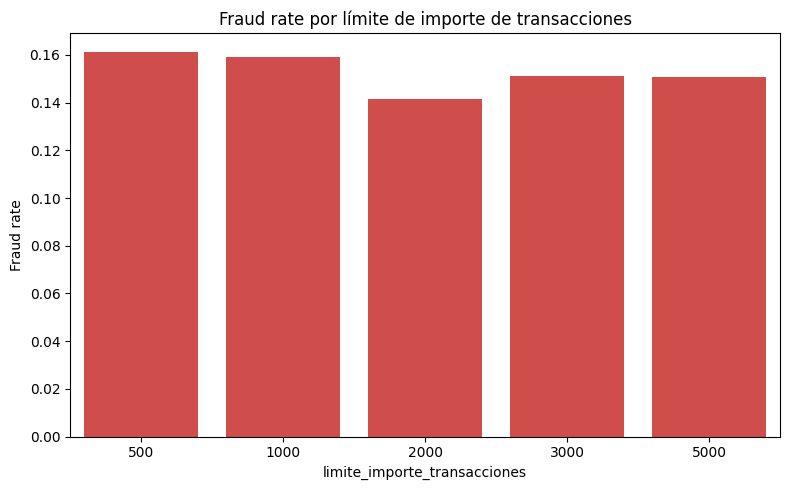

In [60]:
# Limite importe transacciones
resumen_limite = (
    df.groupby('limite_importe_transacciones')['IS_FRAUD']
    .agg(total='size', fraud_rate='mean')
    .reset_index()
    .sort_values('limite_importe_transacciones')
)

display(resumen_limite)

plt.figure(figsize=(8, 5))
sns.barplot(data=resumen_limite, x='limite_importe_transacciones', y='fraud_rate', color='#E53935')
plt.title('Fraud rate por límite de importe de transacciones')
plt.xlabel('limite_importe_transacciones')
plt.ylabel('Fraud rate')
plt.tight_layout()
plt.show()

> **Hallazgo 8.7 — `limite_importe_transacciones` sin señal:**  
> Solo 5 valores posibles (500, 1000, 2000, 3000, 5000). Fraud rate plano en torno al 15% para todos. Correlación con IS_FRAUD de -0.012.  
> **Decisión: fuera del feature set — variable muerta.**

## 9. Conclusiones del EDA

Resumen de los hallazgos clave y decisiones tomadas sobre cada variable tras el análisis exploratorio completo.

### 9.1 Calidad y estructura del dataset

- **10.000 registros**, sin valores nulos, dataset sintético apto para la primera ronda del desafío.
- **Cobertura temporal parcial**: solo están presentes los meses enero–mayo y noviembre–diciembre. Los meses junio–octubre no existen en los datos. No hay estacionalidad relevante entre los meses presentes (fraud rate estable entre 12–16%).
- **Desbalanceo de clases moderado**: 15.26% de fraude (ratio 5.6:1). No es extremo, pero requiere métricas adecuadas y estrategia de entrenamiento.

### 9.2 Variables descartadas

| Variable | Motivo |
|----------|--------|
| `id_cliente`, `id_cuenta`, `id_tarjeta`, `id_transaccion` | Identificadores sin valor predictivo |
| `cuenta_origen` | Artefacto de alta cardinalidad — Cramér's V inflado artificialmente. AUC con/sin ella: 0.706 / 0.706. Sin señal real |
| `identificador_dispositivo_fingerprint`, `direccion_ip_origen`, `geolocalizacion`, `cuenta_destino` | Identificadores o variables que requieren ingeniería compleja fuera del alcance de la Ronda 1 |
| `fecha_hora`, `fecha_creacion_tarjeta` | Fechas en bruto — `antiguedad_tarjeta_dias` ya captura la información relevante |
| `IMPACTO_FRAUDE` | **Leakage total**: correlación 0.89 con IS_FRAUD, es 0 en todos los no-fraude y >0 en todos los fraudes |
| `estado_tarjeta`, `estado_cuenta` | **Riesgo de leakage causal**: no se puede garantizar que reflejen el estado *antes* de la transacción en este dataset sintético |
| `saldo_medio_30_dias` | Redundante con `saldo_actual` (correlación 0.98) |
| `is_night`, `is_weekend` | Sin señal (diferencia < 1.5pp respecto a la base) |
| `numero_transacciones_ultima_hora` | Sin señal (correlación ≈ 0) |
| `veces_superar_limite_7_dias` | Sin señal (correlación ≈ 0, flat por valor) |
| `limite_importe_transacciones` | Sin señal (correlación -0.012, solo 5 valores posibles) |

### 9.3 Variables con señal confirmada

| Variable | Observación |
|----------|-------------|
| `destino_alto_riesgo` | 33.6% fraud rate vs 12.8% — señal fuerte y directa |
| `dispositivo_reconocido` | No reconocido: 22.7% vs reconocido: 13.9% |
| `tipo_transaccion` | Transferencia: 19.3% vs tarjeta: 13.6% |
| `importe_transaccion` | Quintil superior: 21.9% vs base 15.3% |
| `numero_fraudes_ultimo_ano` | Señal creciente válida en valores 0–3 (ver 9.4) |
| Cross-border (derivada) | Operación fuera del país del cliente: 26.7% vs 14.0% |
| `saldo_actual` | Señal débil directa, pero relevante como contexto de la transacción |
| `importe_medio_mensual` | Correlación 0.033, señal débil pero disponible |
| `metodo_autenticacion` | Señal débil pero coherente (3DS más seguro: 14.1%; firma más riesgosa: 17.5%) |
| `numero_pin_disponibles` | Valor 0 alcanza 23.5% fraud rate — señal a confirmar en FE |

### 9.4 Anomalías tratadas

**`numero_fraudes_ultimo_ano`** — La señal es creciente y real para valores 0–3, pero a partir de 4 el fraud rate cae (de 23.4% a 11.1%). El análisis de intervalos de confianza Wilson confirma que la caída es ruido estadístico puro (n=72, n=10, n=1 para valores 4, 5 y 6). Se creará la variable `fraudes_prev_capped = clip(upper=3)`.

**`cuenta_origen`** — El Cramér's V de 0.61 es un artefacto: con 3.548 valores únicos, el chi² se infla mecánicamente. La prueba definitiva es el AUC: con vs sin la variable el resultado es idéntico (0.706). Se descarta sin necesidad de drop explícito — simplemente no se incluye en el feature set.

**`IMPACTO_FRAUDE`** — Correlación perfecta con el target (0.89). Es 0 en el 100% de los no-fraudes y >0 en el 100% de los fraudes. Leakage absoluto, descartada.

### 9.5 Calidad de señal del dataset

Un Random Forest básico (sin feature engineering) sobre las variables numéricas disponibles alcanza **AUC = 0.706** en validación cruzada de 5 folds. Esto confirma que:
- El dataset contiene patrones reales aprendibles.
- Hay margen de mejora significativo mediante feature engineering (cross-border, ratios de importe, cap de fraudes previos).
- El dataset sintético es **apto para la Ronda 1** — no es necesario regenerarlo.

## 10. Recomendaciones — Feature Engineering y Modelado

### 10.1 Feature Engineering prioritario

Las siguientes transformaciones están justificadas por el análisis y deben implementarse antes del primer entrenamiento:

**1. Cap en fraudes previos**
```python
df['fraudes_prev_capped'] = df['numero_fraudes_ultimo_ano'].clip(upper=3)
```
Captura la señal creciente real (r=0.049, p<0.0001 para valores 0–3) sin que 83 registros ruidosos confundan al modelo.

**2. Flag de operación cross-border**
```python
df['cross_border'] = (df['operacion_pais'] != df['customer_country']).astype(int)
```
El 10% de transacciones son cross-border y alcanzan 26.7% de fraud rate vs 14.0%. Señal clara y fácil de construir.

**3. Ratio importe relativo al saldo**
```python
df['ratio_importe_saldo'] = df['importe_transaccion'] / (df['saldo_actual'] + 1)
```
Captura si la transacción es grande en relación al saldo disponible — más informativo que el importe absoluto.

**4. Ratio importe vs comportamiento habitual**
```python
df['ratio_importe_media'] = df['importe_transaccion'] / (df['importe_medio_mensual'] + 1)
```
Detecta transacciones atípicas respecto al perfil habitual del cliente.

### 10.2 Feature Engineering secundario (segunda iteración)

Una vez validado el modelo base con las features prioritarias:

- **Mes de la transacción**: extraer de `fecha_hora` — cobertura parcial pero puede capturar algún patrón estacional.
- **`numero_pin_disponibles`**: valor 0 muestra 23.5% de fraud rate — requiere análisis más detallado antes de incluirlo directamente.
- **`metodo_autenticacion`**: señal débil pero coherente, puede aportar algo con encoding adecuado.
- **Interacciones**: `destino_alto_riesgo × dispositivo_reconocido` ya mostró ser el cruce más potente del análisis multivariante.

### 10.3 Preprocesamiento

- **Escalado**: usar `RobustScaler` para las variables numéricas — son asimétricas y con outliers, es más robusto que StandardScaler.
- **Encoding categórico**: para `tipo_transaccion`, `metodo_autenticacion` y `tipo_cliente` usar One-Hot Encoding (pocas categorías). Para variables de alta cardinalidad como `customer_country` u `operacion_pais`, considerar Target Encoding con smoothing para evitar overfitting.
- **Variables de fecha**: no usar en bruto — extraer componentes relevantes (mes, hora) o calcular antigüedades.

### 10.4 Estrategia de modelado

**Métricas**: usar **AUC-ROC** como métrica principal y **F1-score** como secundaria. Evitar accuracy — con 15.3% de fraude un modelo que predice siempre "no fraude" alcanza 84.7% de accuracy, lo que es engañoso.

**Desbalanceo de clases**: aplicar `class_weight='balanced'` en el modelo. Como alternativa o complemento, explorar SMOTE en la fase de experimentación.

**Modelos recomendados**:
1. **Random Forest** como baseline (AUC 0.706 ya conseguido sin FE).
2. **XGBoost o LightGBM** como candidato principal — manejan bien variables mixtas, imbalance y relaciones no lineales.

**Validación**: **5-fold cross-validation estratificada** (preserva la proporción de fraude en cada fold). Usar los mismos folds para comparar modelos.

**Umbral de decisión**: el umbral por defecto (0.5) probablemente no sea óptimo. Ajustar según el trade-off precisión/recall que defina negocio — en fraude suele preferirse recall alto (no dejar pasar fraudes) aunque baje la precisión.

**Feature importance**: analizar tras el primer entrenamiento para confirmar o descartar variables de señal débil (`metodo_autenticacion`, `numero_pin_disponibles`, variables de volumen).